In [1]:
import pandas as pd
from src.balancing import run_experiments_single_dataset #run_all_experiments

In [2]:
# =================================================================
# STEP 1: LOAD MERGE FILE BARU (Kappa 0.86, sudah preprocessed)
# =================================================================

# Load merge file dari notebook_merimo (full_text sudah bersih)
df_kesepakatan = pd.read_csv('notebook_merimo/data_merge_rendika_fadly.csv')

# Rename kolom agar kompatibel dengan pipeline (clean_text + label)
df_kesepakatan = df_kesepakatan.rename(columns={
    'full_text': 'clean_text',
    'label_rendika': 'label'
})

# Bersihkan NaN dan teks kosong
df_kesepakatan = df_kesepakatan.dropna(subset=['clean_text'])
df_kesepakatan = df_kesepakatan[df_kesepakatan['clean_text'].str.strip() != '']

print(f'Loaded: {len(df_kesepakatan)} rows (after NaN cleanup)')
print(f'Distribusi label: {df_kesepakatan["label"].value_counts().to_dict()}')
print(df_kesepakatan[['clean_text', 'label']].head())

Loaded: 35033 rows (after NaN cleanup)
Distribusi label: {0: 27096, 1: 6949, 2: 988}
                                          clean_text  label
0  Oh ternyata bestienya koruptor kakap pertamina...      0
1  Salah satu kelebihan pertamax oplosan bisa mer...      0
2                                       Belum jg win      1
3  @Bang_Ramzan Td pagi buka tiktok ada yg lucu S...      0
4  Herman khaeron dan amplop pertamina ? #pertama...      0


In [3]:
import marimo as mo

#Eksperimen

In [4]:
all_results = run_experiments_single_dataset(df_kesepakatan, kolom_y='label')


PREPARE FEATURES - Dataset

Dataset:
  Shape fitur TF-IDF Train: (28026, 5000)
  Shape fitur TF-IDF Test: (7007, 5000)
  Jumlah fitur train: 5000
  Jumlah fitur test: 5000

######################################################################
  DATASET: Dataset
######################################################################

>> Dataset | No_Balancing | MLP Baseline
  Run 1/3 (seed=42)... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Acc=0.6950 | F1=0.7004
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Acc=0.6973 | F1=0.7024
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Acc=0.6927 | F1=0.6988
  >> RATA-RATA: Acc=0.6950 (±0.0019) | F1=0.7005 (±0.0015)

>> Dataset | No_Balancing | MLP Advanced
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Acc=0.7959 | F1=0.7524
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2m

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Acc=0.7901 | F1=0.7449
  1/219 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Acc=0.7942 | F1=0.7490
  Run 3/3 (seed=456)... 

...

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Acc=0.7450 | F1=0.7215
  1/219 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Acc=0.7353 | F1=0.7220
  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Acc=0.7331 | F1=0.7234
  >> RATA-RATA: Acc=0.7378 (±0.0052) | F1=0.7223 (±0.0008)

>> Dataset | SMOTETomek | Naive Bayes
  Run 1/3 (seed=42)... Acc=0.6709 | F1=0.6940
  Run 2/3 (seed=123)... Acc=0.6679 | F1=0.6918
  Run 3/3 (seed=456)... Acc=0.6733 | F1=0.6963
  >> RATA-RATA: Acc=0.6707 (±0.0022) | F1=0.6940 (±0.0018)

>> Dataset | SMOTETomek | SVM
  Run 1/3 (seed=42)... Acc=0.6962 | F1=0.7121
  Run 2/3 (seed=123)... Acc=0.6944 | F1=0.7109
  Run 3/3 (seed=456)... Acc=0.6967 | F1=0.7124
  >> RATA-RATA: Acc=0.6958 (±0.0010) | F1=0.7118 (±0.0006)

>> Dataset | SMOTETomek | Random Forest
  Run 1/3 (seed=42)... Acc=0.7826 | F1=0.7642
  Run 2/3 (seed=123)... Acc=0.7814 | F1=0.7631
  Run 3/3 (seed=456)... Acc=0.7809 | F1=0.7626
  >> RATA-RATA: Acc=0.7816 (±0.0007) | F1=0.7633 (±0.0007)

>> Dataset | SMOTETomek | Logistic Regression
  Run 1/3 (seed=42)... Acc=0.6765 | F1=0.6997
  Run 2/3 (seed=123)... Acc=0.6738 | F1=0.6979
  Run 3/3 (seed=456)... Acc=0

In [5]:
import json
import numpy as np

In [6]:
def convert_results(obj):
    if isinstance(obj, dict):
        return {k: convert_results(v) for k,v in obj.items()}
    elif isinstance(obj, list):
        return [convert_results(i) for i in obj]
    elif isinstance(obj,(np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj


with open('results/all_results.json)','w') as f:
    json.dump(convert_results(all_results), f,indent=2)

#untuk load json
#with open('results/all_results.json', 'r') as f:
    #all_results =json.load(f)

In [7]:
from src.evaluation import print_all_metrics_table, find_best_model

In [8]:
# Langkah 1: Bungkus ulang variabel hasil running ke dalam dict baru
all_results_fixed = {'Dataset_A': all_results}

print("--- Menampilkan Tabel Metrik Berhasil ---")
# Langkah 2: Panggil tabel menggunakan variabel baru yang sudah dibungkus
print_all_metrics_table(all_results_fixed)

print("\n--- Mencari Model Terbaik ---")
# Langkah 3: Panggil fungsi pencari model terbaik dengan variabel baru yang benar
best_acc = find_best_model(all_results_fixed, metric='accuracy')
best_pre = find_best_model(all_results_fixed, metric='precision')
best_reca = find_best_model(all_results_fixed, metric='recall')
best_f1 = find_best_model(all_results_fixed, metric='f1')

# Langkah 4: Cetak hasilnya ke layar
print("Best Accuracy :", best_acc)
print("Best Precision:", best_pre)
print("Best Recall   :", best_reca)
print("Best F1-Score :", best_f1)

--- Menampilkan Tabel Metrik Berhasil ---

RATA-RATA ACCURACY (3 RUNS) - Dataset_A
Model                     No_Balancing             ROS           SMOTE             RUS        SMOTEENN      SMOTETomek
----------------------------------------------------------------------------------------------------------------------
MLP Baseline            0.6950±0.0019  0.7503±0.0028  0.7638±0.0012  0.4715±0.0089  0.2522±0.0072  0.7635±0.0033
MLP Advanced            0.7924±0.0025  0.7640±0.0026  0.7453±0.0051  0.3921±0.2689  0.2379±0.0031  0.7423±0.0026
MLP Keras Tuner         0.7923±0.0017  0.7676±0.0028  0.7349±0.0140  0.3551±0.2351  0.2388±0.0079  0.7378±0.0052
Naive Bayes             0.7885±0.0000  0.6567±0.0022  0.6717±0.0022  0.5480±0.0042  0.1947±0.0003  0.6707±0.0022
SVM                     0.7946±0.0000  0.6392±0.0040  0.6964±0.0008  0.5227±0.0112  0.2282±0.0025  0.6958±0.0010
Random Forest           0.8003±0.0009  0.7889±0.0020  0.7808±0.0014  0.5280±0.0180  0.2295±0.0013  0.7816±0.0007
L

In [9]:
import json

# Mengamankan hasil running 18 jam ke dalam file harddisk
with open('results/all_results.json', 'w') as f:
    json.dump(convert_results(all_results_fixed), f, indent=2)

In [10]:
print_all_metrics_table(all_results)
best_acc = find_best_model(all_results, metric='accuracy')
best_pre = find_best_model(all_results, metric='precision')
best_reca = find_best_model(all_results, metric='recall')
best_f1 = find_best_model(all_results, metric='f1')

KeyError: 'accuracy'

In [12]:
# EValuasi

import os, gc
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
import keras_tuner as kt

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN,SMOTETomek

from src.models import (
    create_mlp_baseline, create_mlp_advance, make_tuner_builder,create_naive_bayes, create_logistic_regression, create_random_forest, create_svm, get_callbacks, MODEL_CONFIGS
)

from src.balancing import BALANCING_METHODS
from src.evaluation import (
    plot_confusion_matrix,
    plot_roc_curve,
    plot_learning_curve,
    print_all_metrics_table,
    print_classification_report,
    find_best_model
)

SEED=42

In [13]:
def prepare(df, kx, ky):
    X_tr, X_te, y_tr, y_te = train_test_split(df[kx], df[ky], test_size=0.2, random_state=SEED)

    tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1,2))

    return tfidf.fit_transform(X_tr), tfidf.transform(X_te), to_categorical(y_tr,3), to_categorical(y_te,3)

data_prepared = {
    'Dataset_A': prepare(df_kesepakatan, 'clean_text', 'label'),
    #'Dataset_B': prepare(df_fadly, 'clean_text', 'label'),
}


[1/42] MLP Baseline + No_Balancing (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report: MLP Baseline + No_Balancing (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.81      0.97      0.88      5412
      Netral       0.65      0.22      0.33      1415
     Positif       0.70      0.13      0.22       180

    accuracy                           0.80      7007
   macro avg       0.72      0.44      0.48      7007
weighted avg       0.77      0.80      0.75      7007

  Saved: results/dataset_kesepakatan/MLP_Baseline/No_Balancing_cm.png


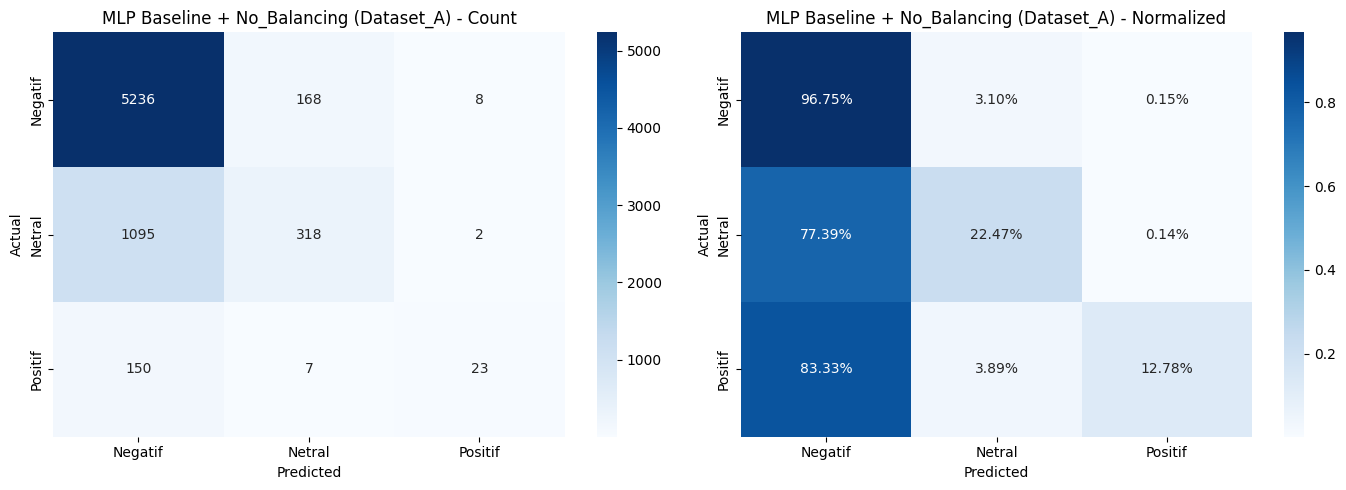

  Saved: results/dataset_kesepakatan/MLP_Baseline/No_Balancing_roc.png


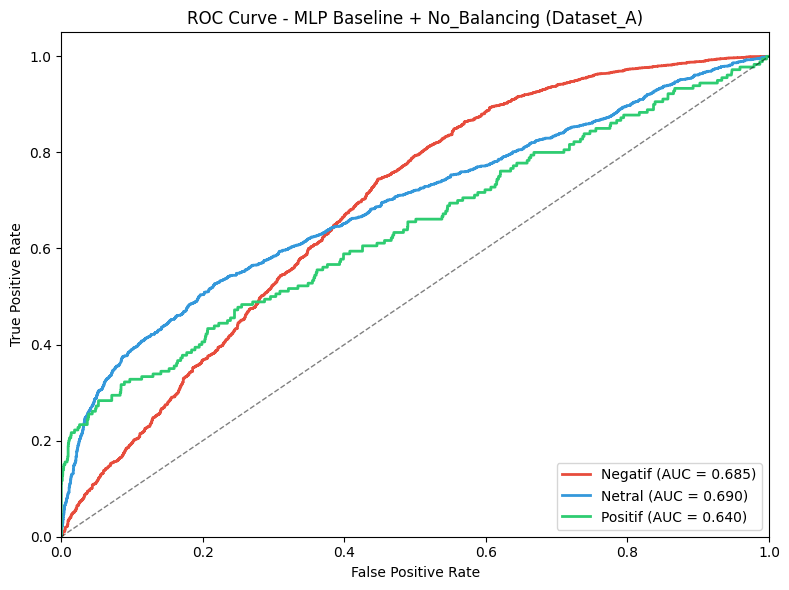

  Saved: results/dataset_kesepakatan/MLP_Baseline/No_Balancing_learning.png


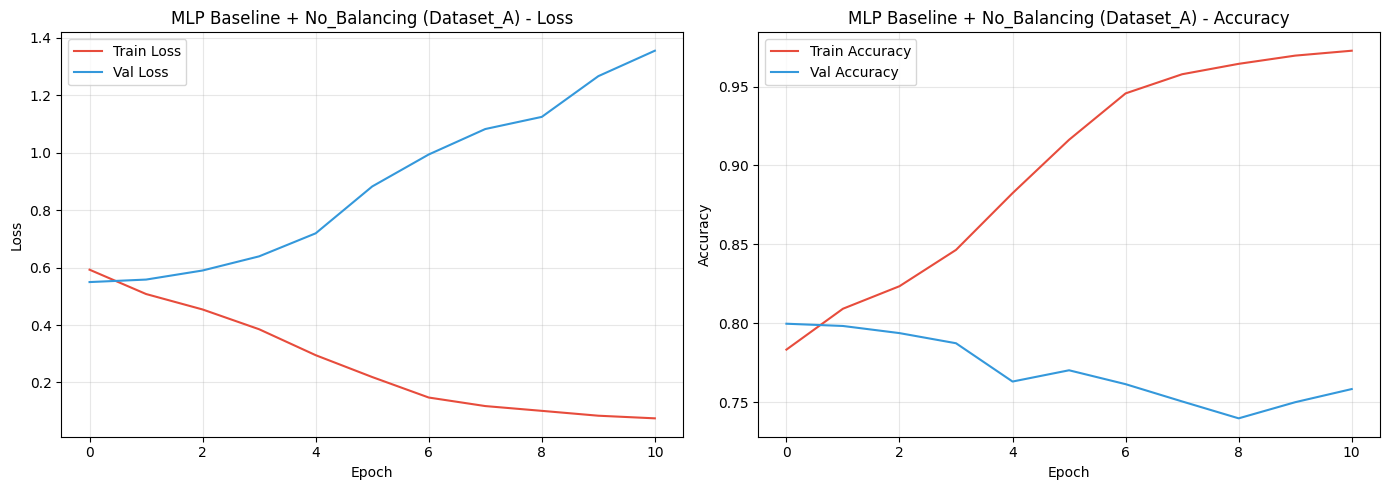

  Acc=0.7959 | F1=0.7529

[2/42] MLP Baseline + ROS (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Classification Report: MLP Baseline + ROS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.82      0.85      0.83      5412
      Netral       0.39      0.34      0.36      1415
     Positif       0.19      0.18      0.18       180

    accuracy                           0.73      7007
   macro avg       0.46      0.45      0.46      7007
weighted avg       0.72      0.73      0.72      7007

  Saved: results/dataset_kesepakatan/MLP_Baseline/ROS_cm.png


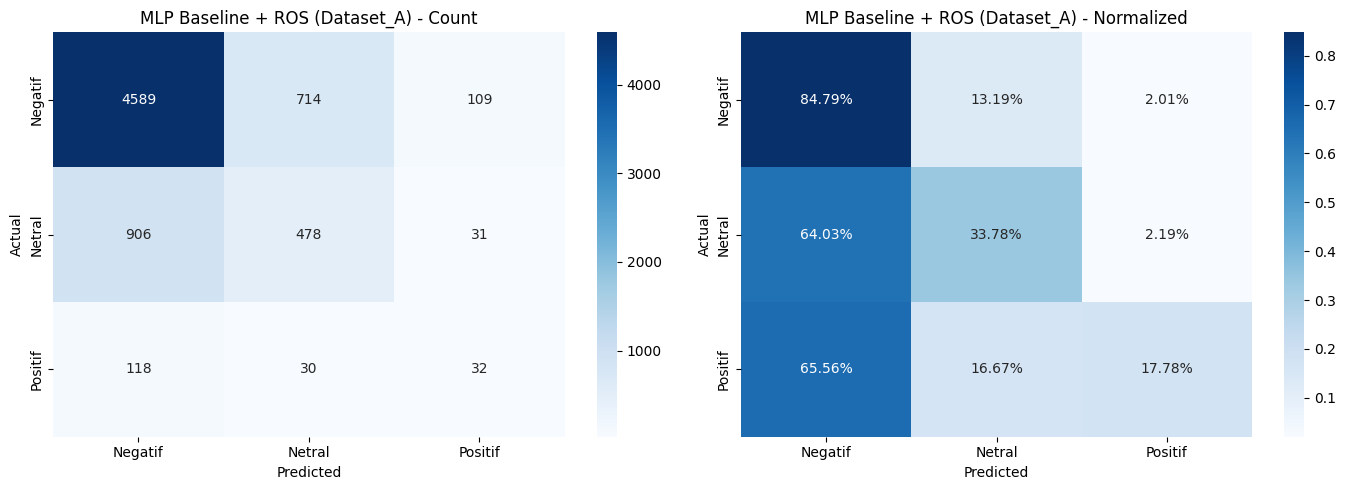

  Saved: results/dataset_kesepakatan/MLP_Baseline/ROS_roc.png


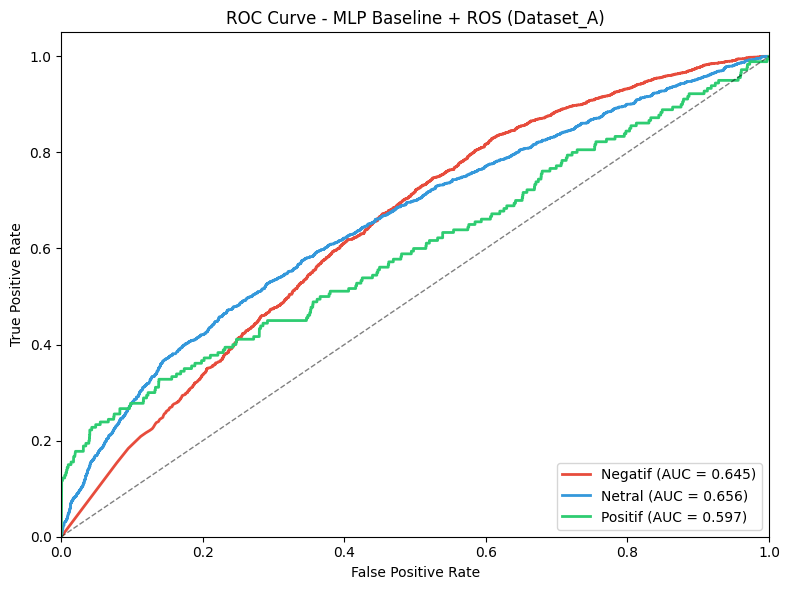

  Saved: results/dataset_kesepakatan/MLP_Baseline/ROS_learning.png


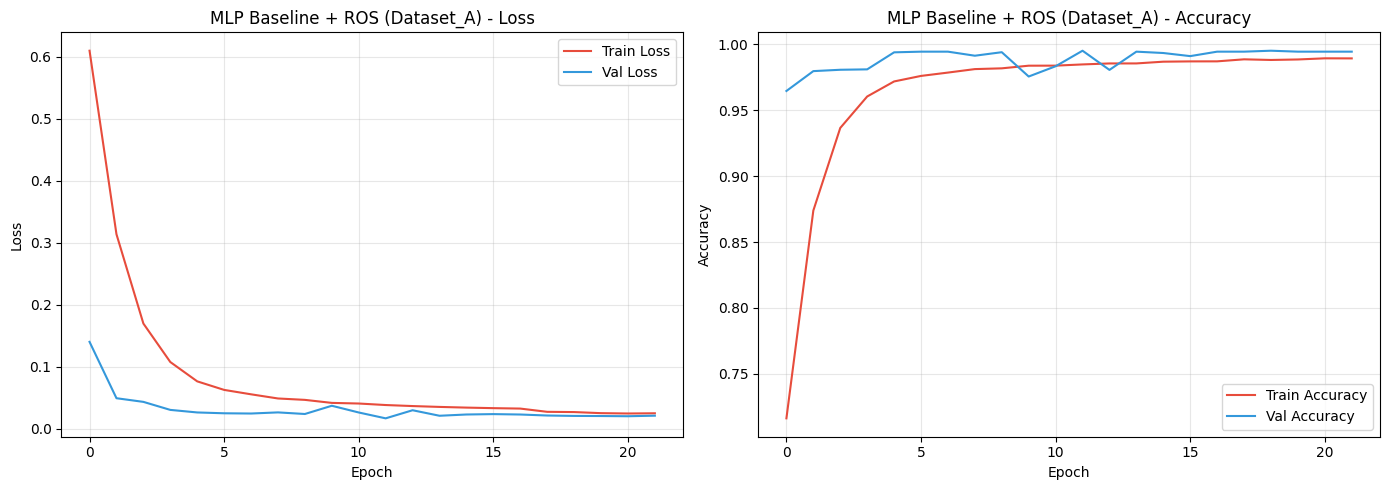

  Acc=0.7277 | F1=0.7209

[3/42] MLP Baseline + SMOTE (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report: MLP Baseline + SMOTE (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.81      0.90      0.85      5412
      Netral       0.42      0.25      0.32      1415
     Positif       0.20      0.15      0.17       180

    accuracy                           0.75      7007
   macro avg       0.47      0.43      0.44      7007
weighted avg       0.71      0.75      0.72      7007

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTE_cm.png


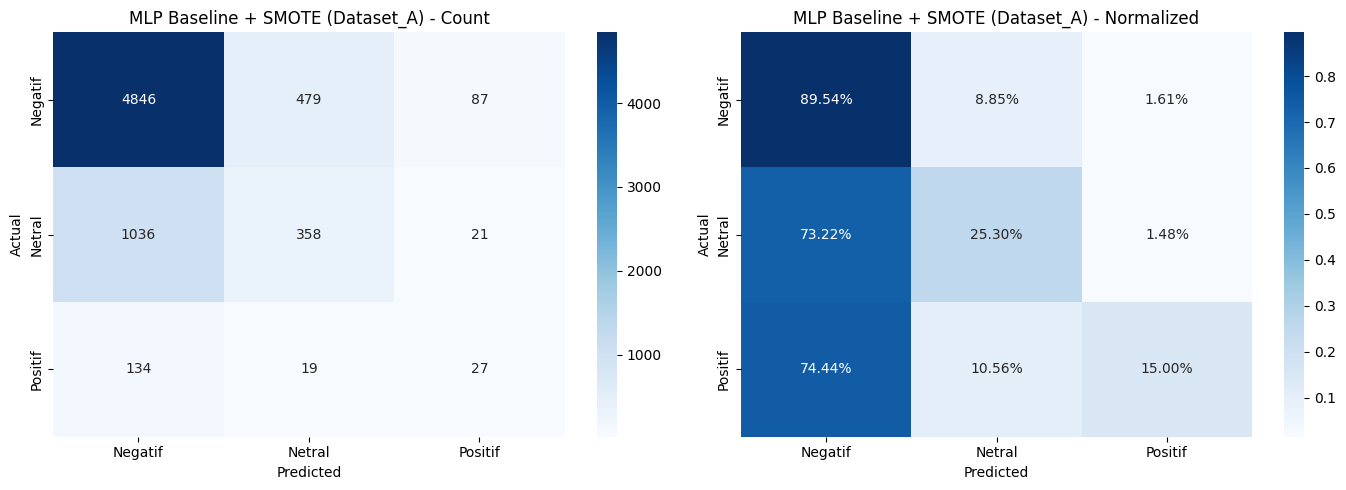

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTE_roc.png


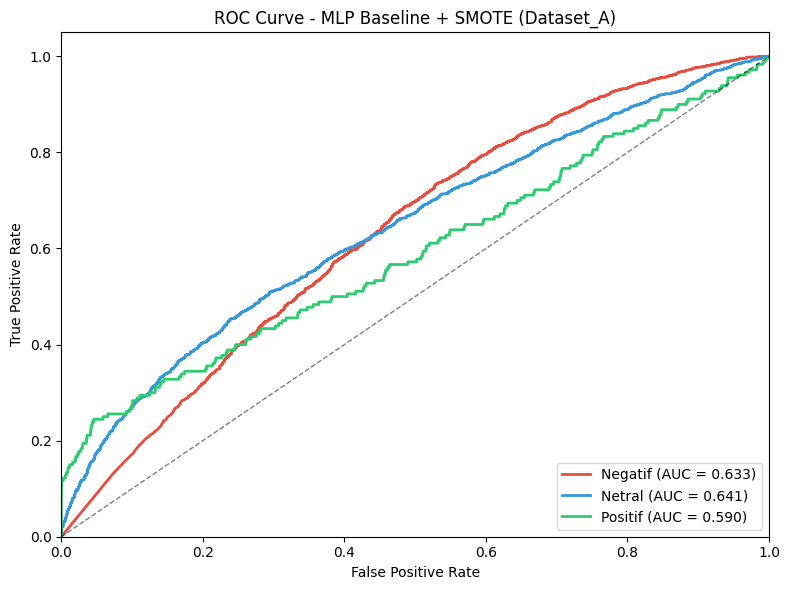

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTE_learning.png


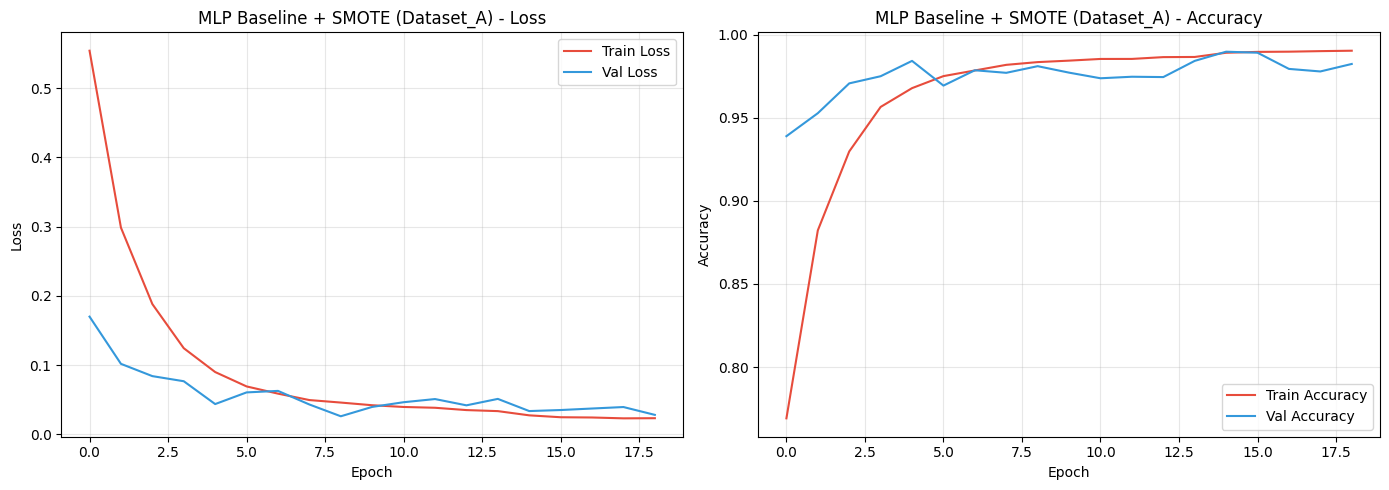

  Acc=0.7465 | F1=0.7231

[4/42] MLP Baseline + RUS (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Classification Report: MLP Baseline + RUS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.85      0.53      0.65      5412
      Netral       0.27      0.64      0.38      1415
     Positif       0.15      0.26      0.19       180

    accuracy                           0.54      7007
   macro avg       0.42      0.48      0.41      7007
weighted avg       0.71      0.54      0.59      7007

  Saved: results/dataset_kesepakatan/MLP_Baseline/RUS_cm.png


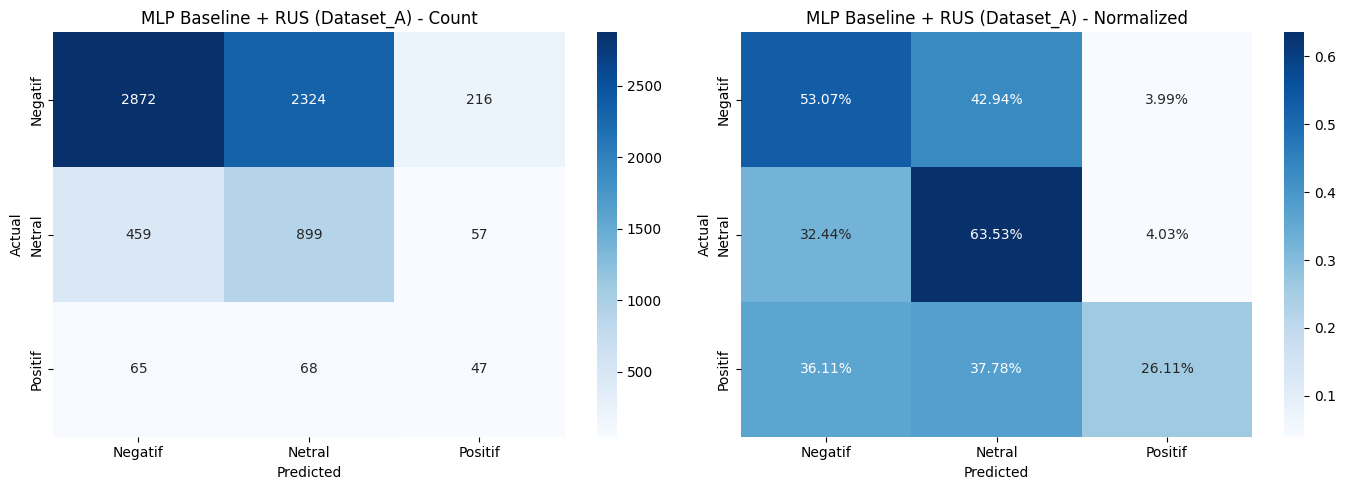

  Saved: results/dataset_kesepakatan/MLP_Baseline/RUS_roc.png


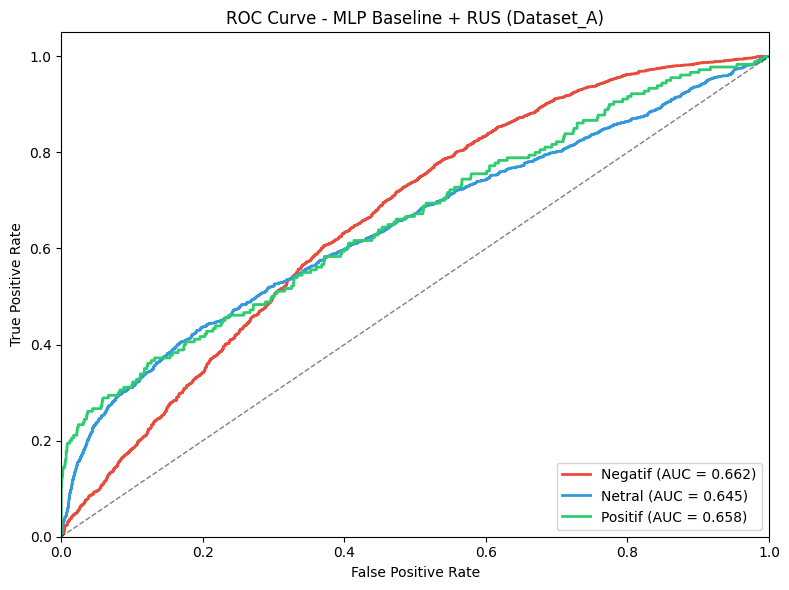

  Saved: results/dataset_kesepakatan/MLP_Baseline/RUS_learning.png


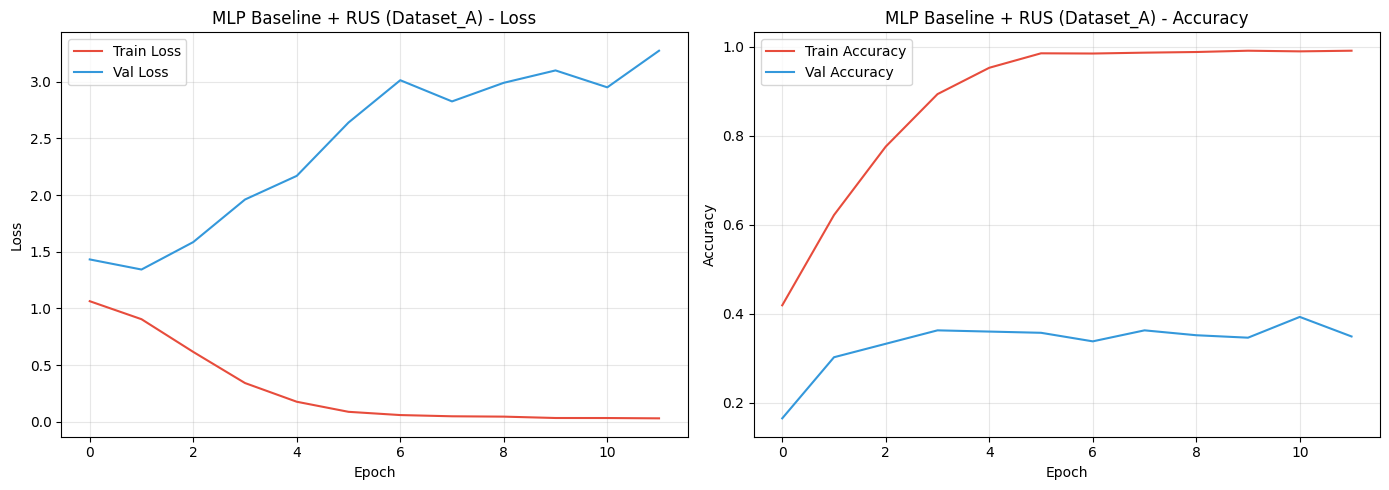

  Acc=0.5449 | F1=0.5857

[5/42] MLP Baseline + SMOTEENN (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Classification Report: MLP Baseline + SMOTEENN (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.85      0.10      0.17      5412
      Netral       0.22      0.81      0.34      1415
     Positif       0.05      0.33      0.09       180

    accuracy                           0.25      7007
   macro avg       0.37      0.41      0.20      7007
weighted avg       0.70      0.25      0.21      7007

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTEENN_cm.png


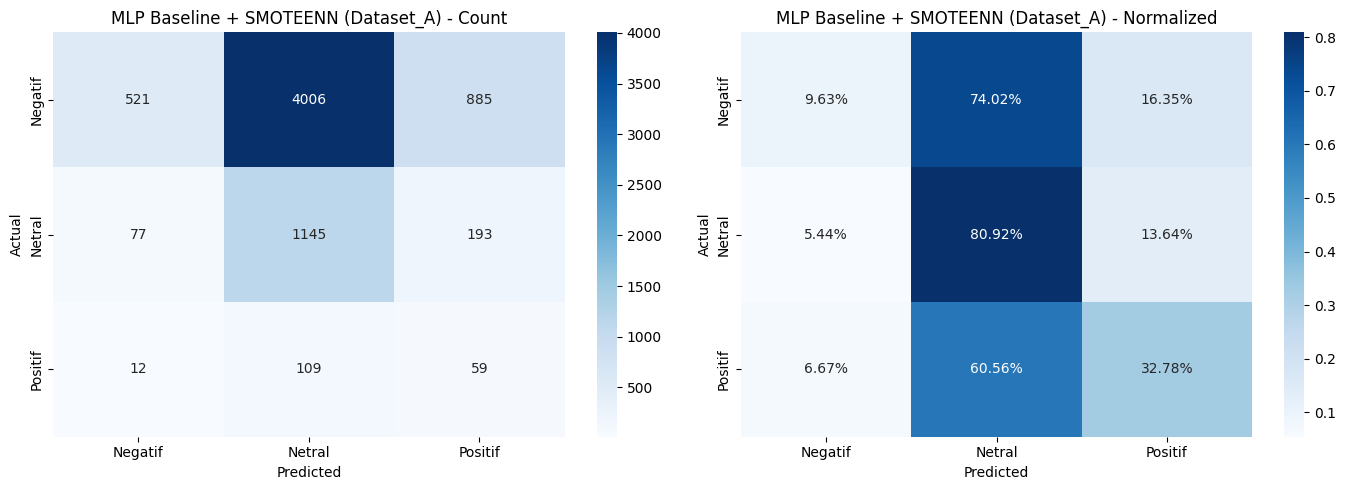

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTEENN_roc.png


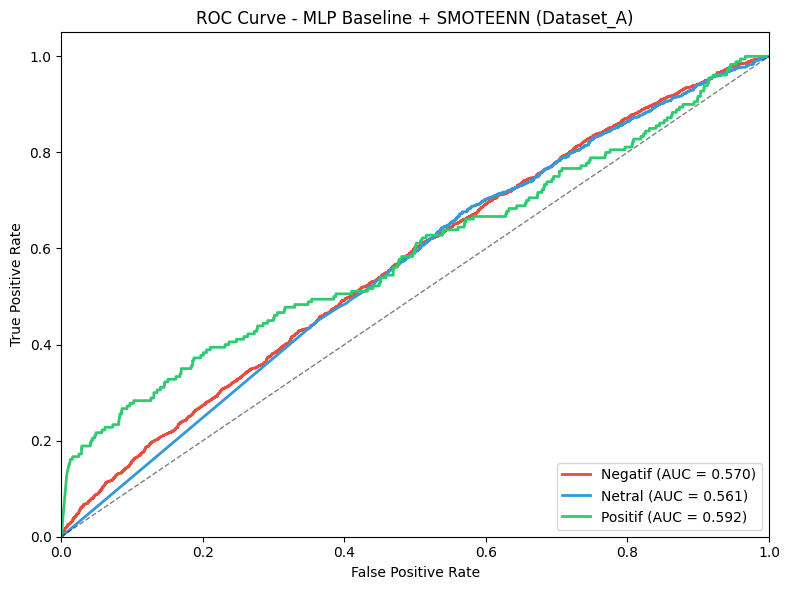

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTEENN_learning.png


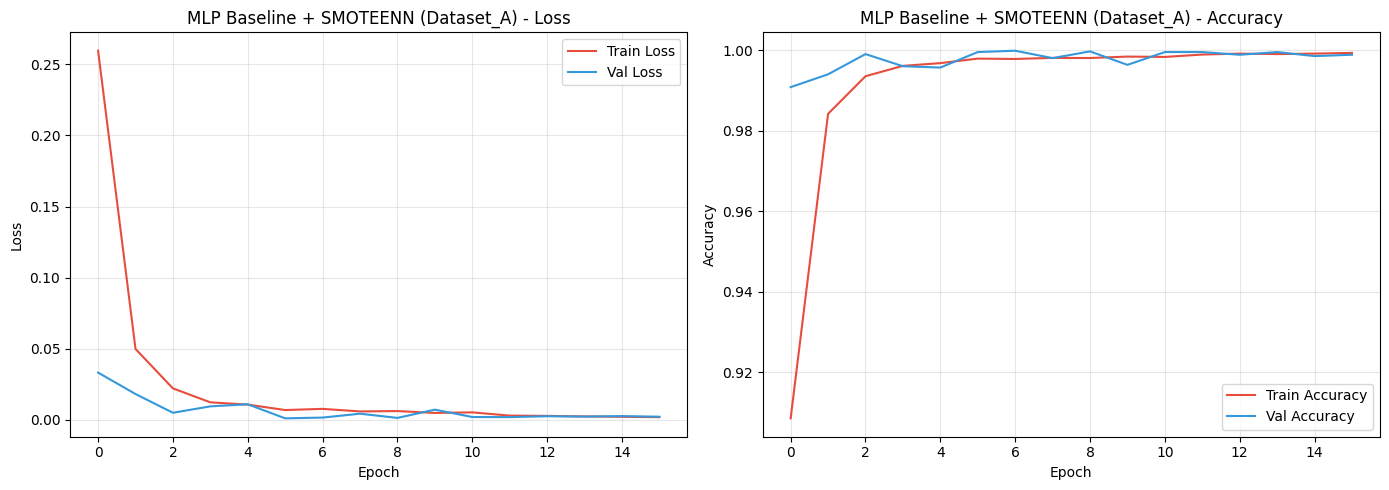

  Acc=0.2462 | F1=0.2052

[6/42] MLP Baseline + SMOTETomek (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report: MLP Baseline + SMOTETomek (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.80      0.95      0.87      5412
      Netral       0.48      0.17      0.25      1415
     Positif       0.41      0.14      0.21       180

    accuracy                           0.77      7007
   macro avg       0.56      0.42      0.44      7007
weighted avg       0.72      0.77      0.72      7007

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTETomek_cm.png


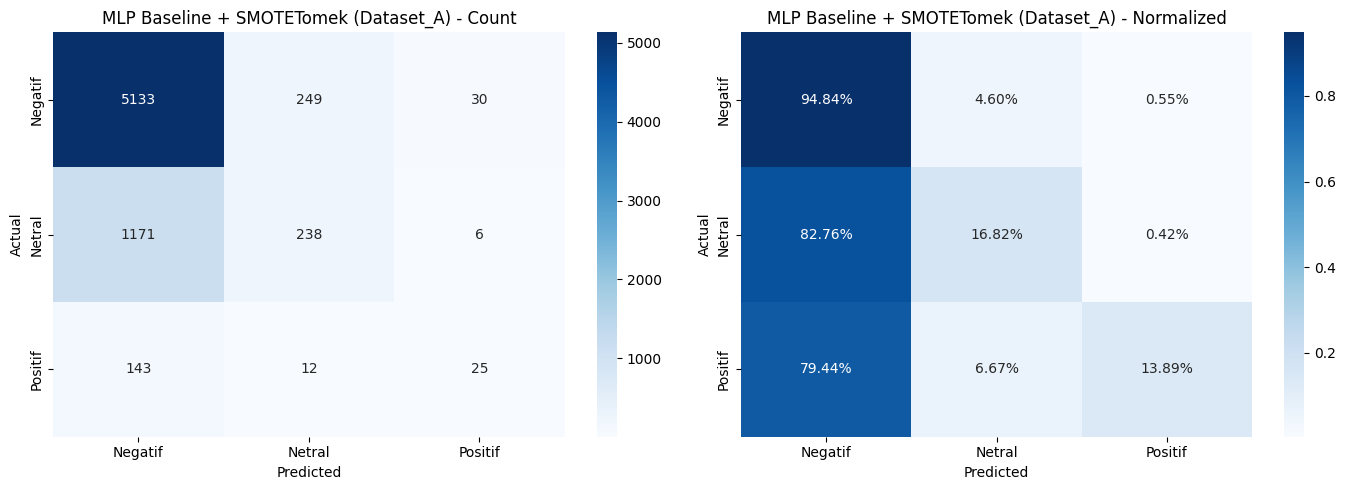

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTETomek_roc.png


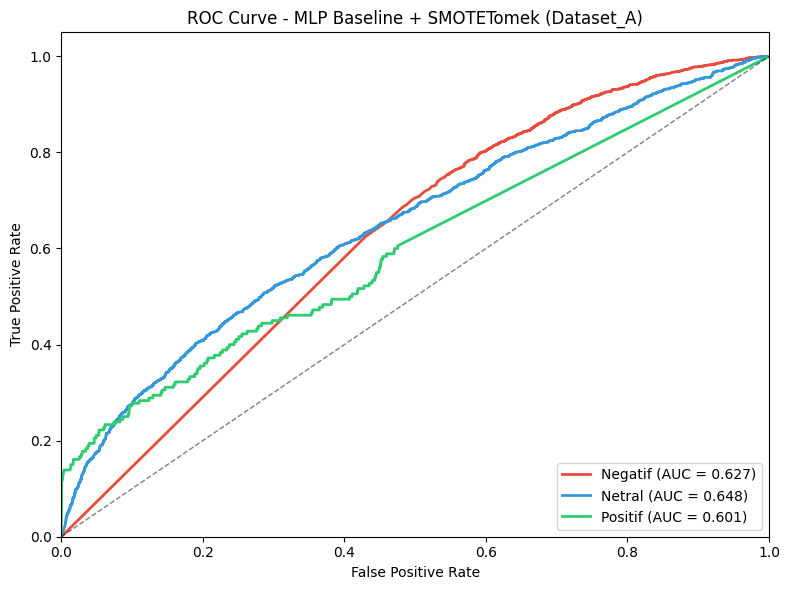

  Saved: results/dataset_kesepakatan/MLP_Baseline/SMOTETomek_learning.png


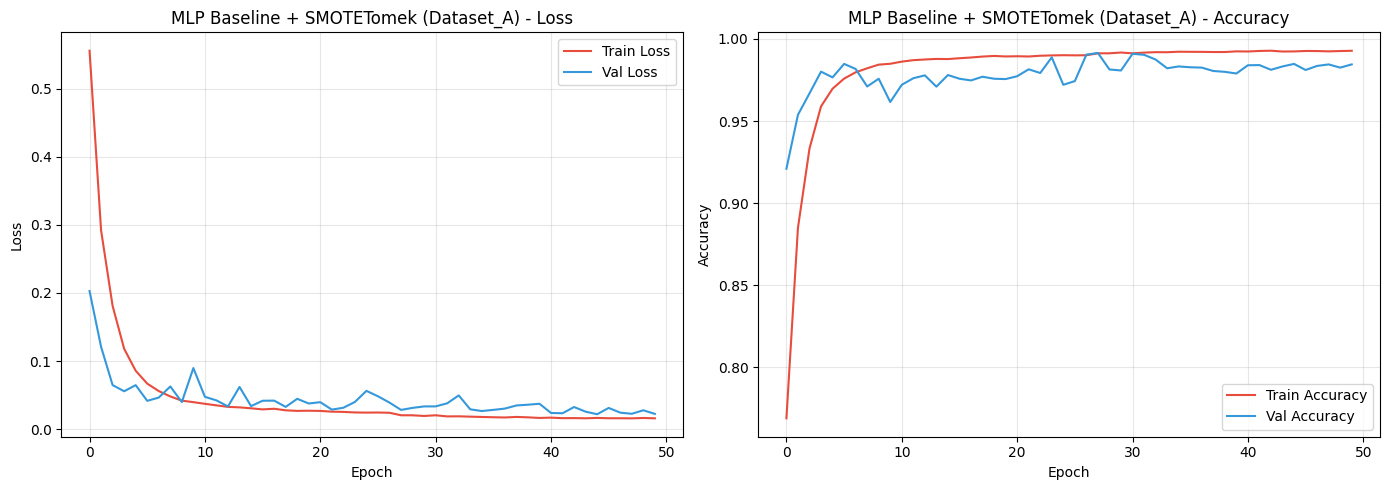

  Acc=0.7701 | F1=0.7242

[7/42] MLP Advanced + No_Balancing (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Classification Report: MLP Advanced + No_Balancing (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.80      0.98      0.88      5412
      Netral       0.66      0.17      0.28      1415
     Positif       0.70      0.12      0.20       180

    accuracy                           0.79      7007
   macro avg       0.72      0.42      0.45      7007
weighted avg       0.77      0.79      0.74      7007

  Saved: results/dataset_kesepakatan/MLP_Advanced/No_Balancing_cm.png


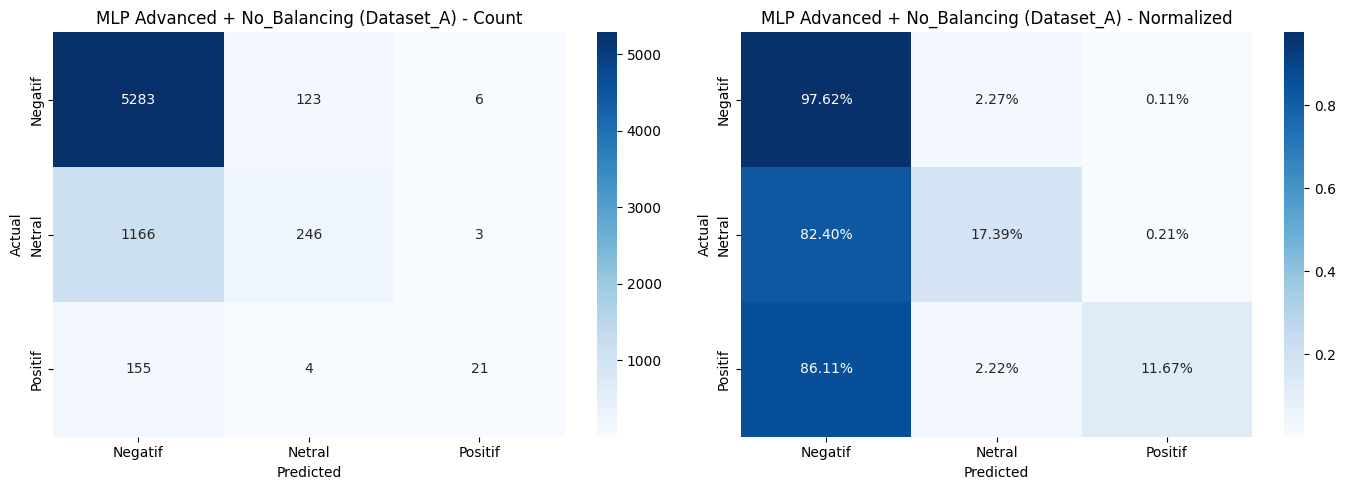

  Saved: results/dataset_kesepakatan/MLP_Advanced/No_Balancing_roc.png


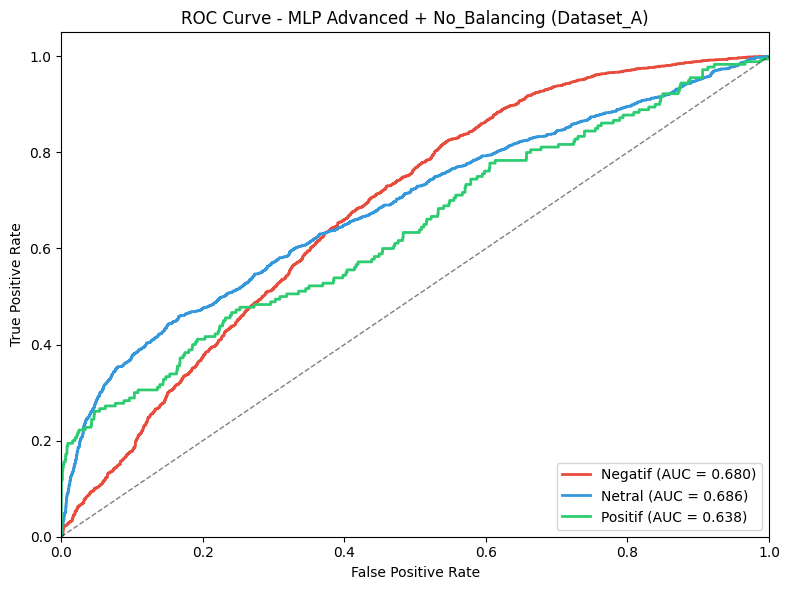

  Saved: results/dataset_kesepakatan/MLP_Advanced/No_Balancing_learning.png


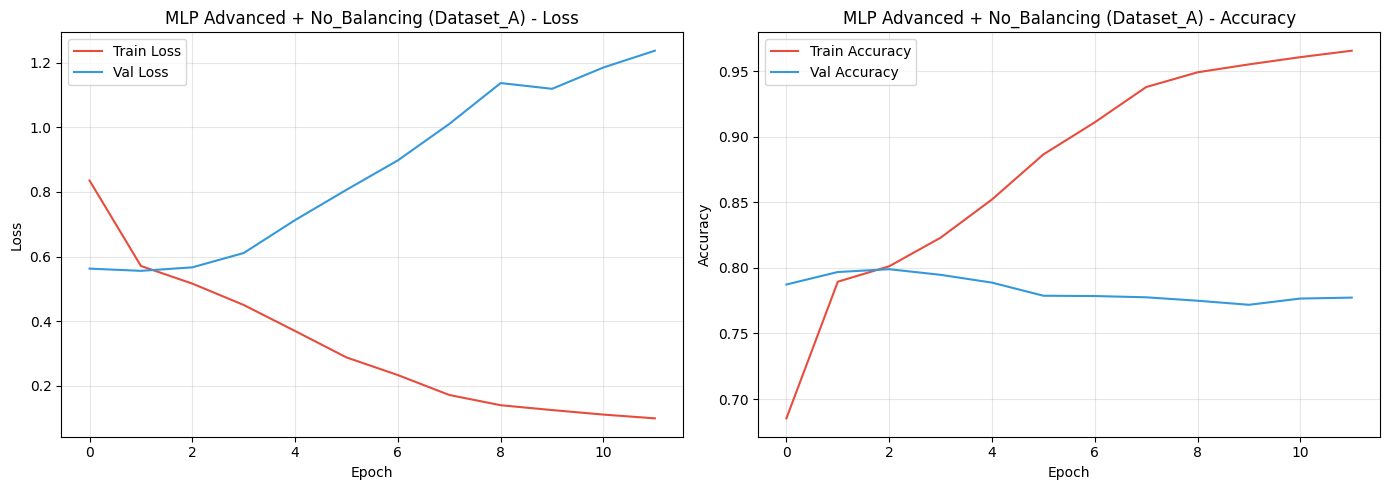

  Acc=0.7921 | F1=0.7399

[8/42] MLP Advanced + ROS (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Classification Report: MLP Advanced + ROS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.81      0.93      0.86      5412
      Netral       0.49      0.25      0.33      1415
     Positif       0.30      0.14      0.19       180

    accuracy                           0.77      7007
   macro avg       0.53      0.44      0.46      7007
weighted avg       0.73      0.77      0.74      7007

  Saved: results/dataset_kesepakatan/MLP_Advanced/ROS_cm.png


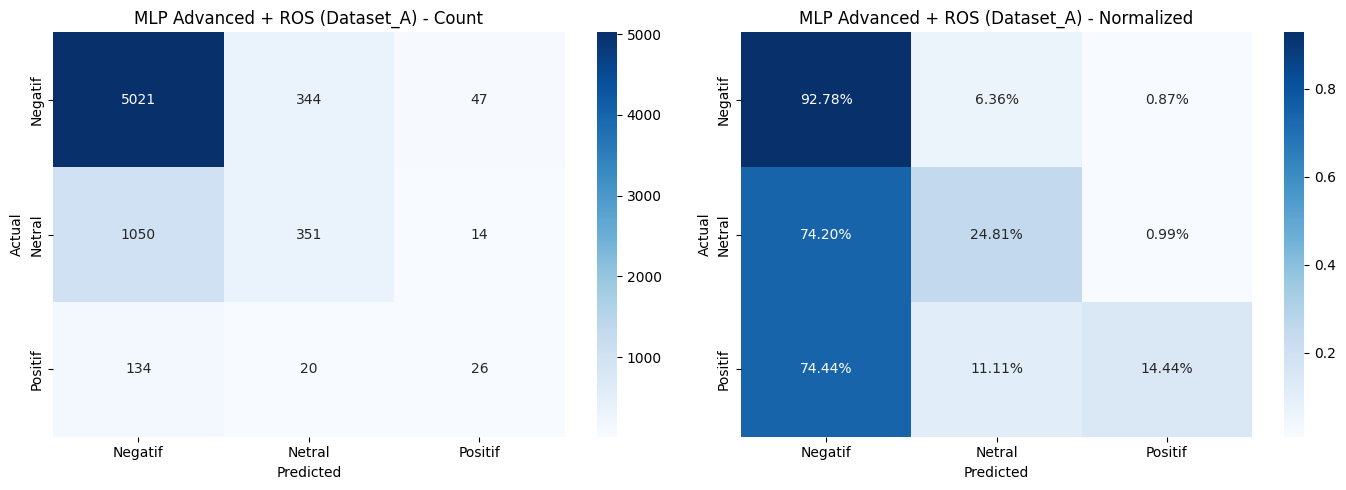

  Saved: results/dataset_kesepakatan/MLP_Advanced/ROS_roc.png


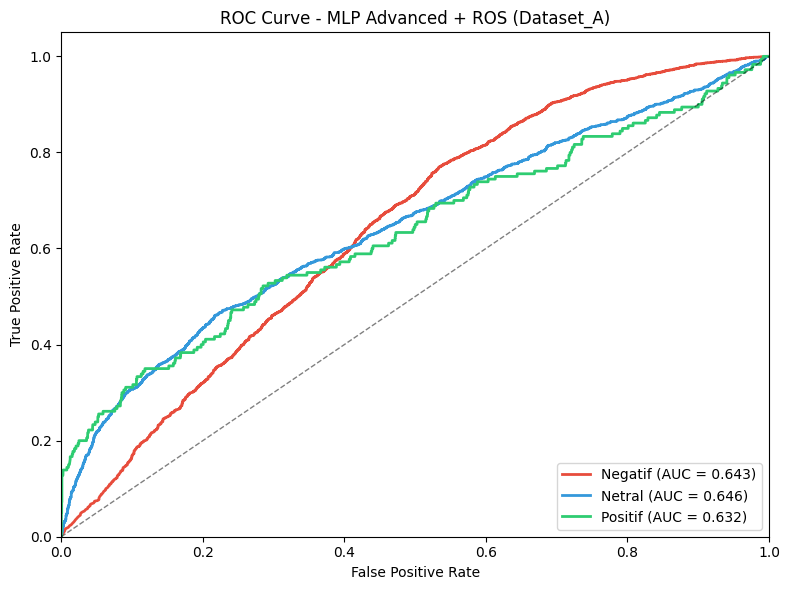

  Saved: results/dataset_kesepakatan/MLP_Advanced/ROS_learning.png


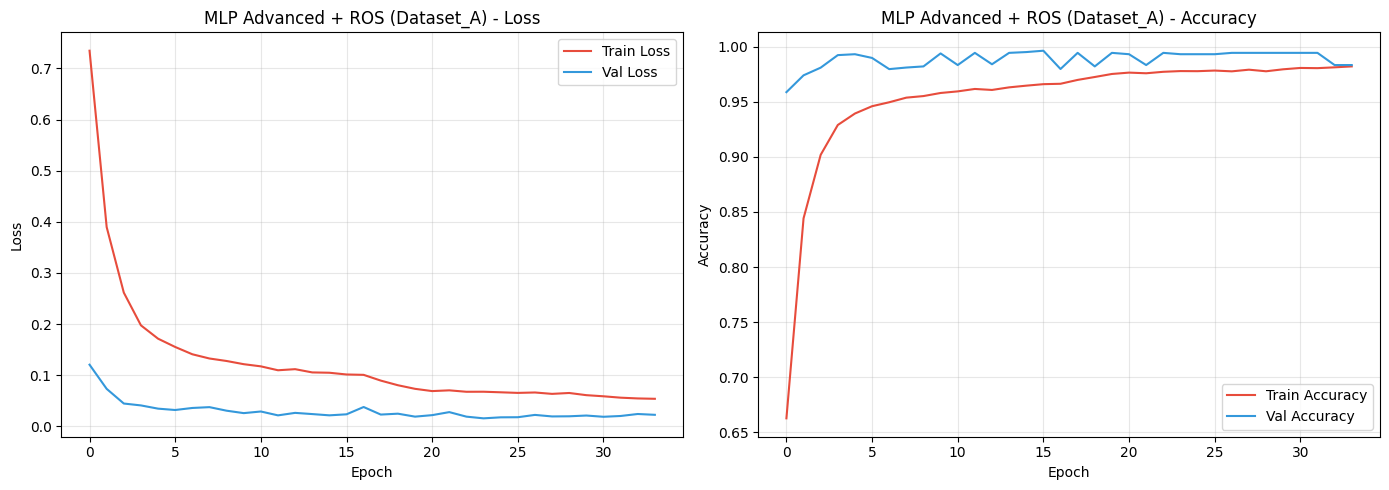

  Acc=0.7704 | F1=0.7392

[9/42] MLP Advanced + SMOTE (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Classification Report: MLP Advanced + SMOTE (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.82      0.87      0.84      5412
      Netral       0.41      0.32      0.36      1415
     Positif       0.25      0.17      0.20       180

    accuracy                           0.74      7007
   macro avg       0.49      0.45      0.47      7007
weighted avg       0.72      0.74      0.73      7007

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTE_cm.png


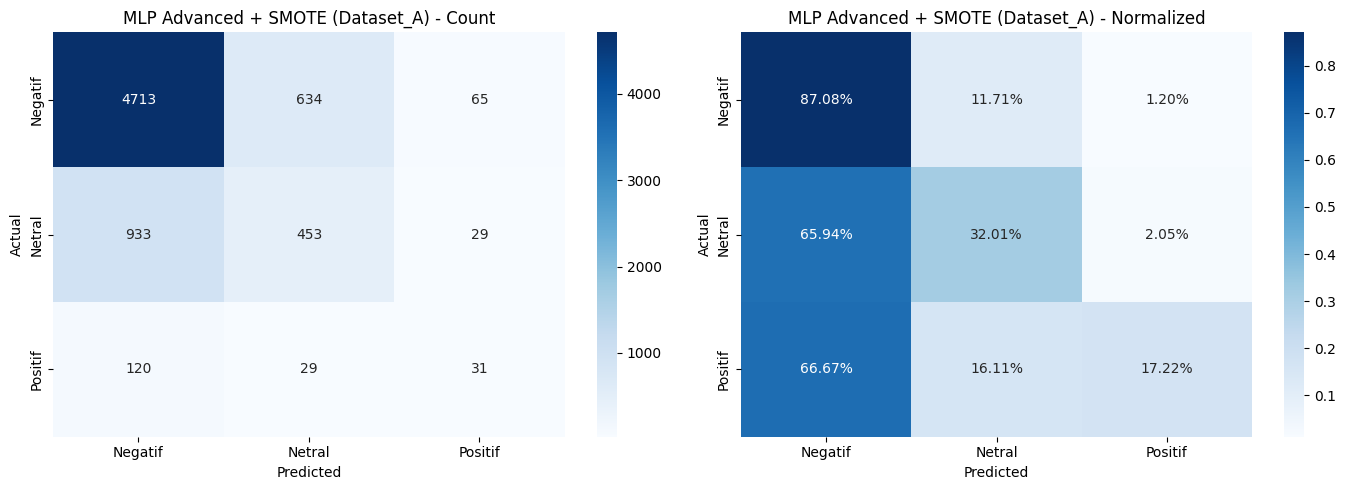

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTE_roc.png


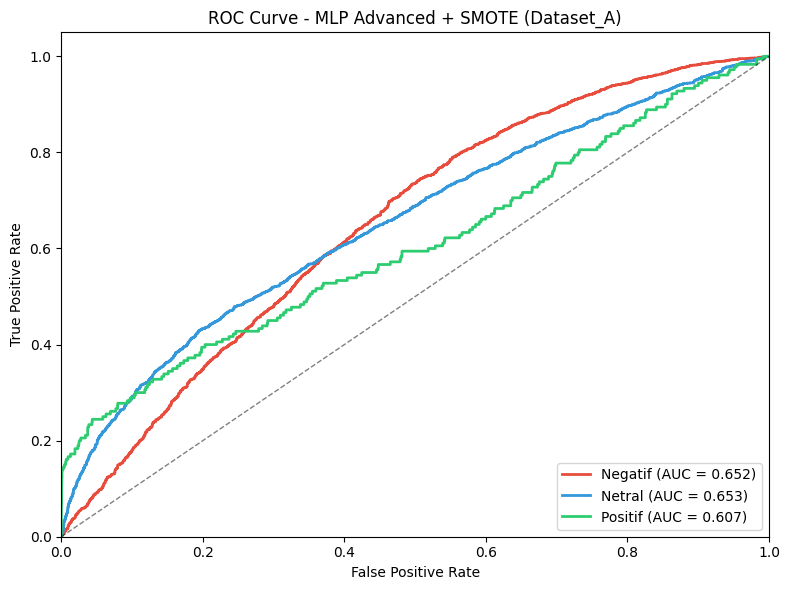

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTE_learning.png


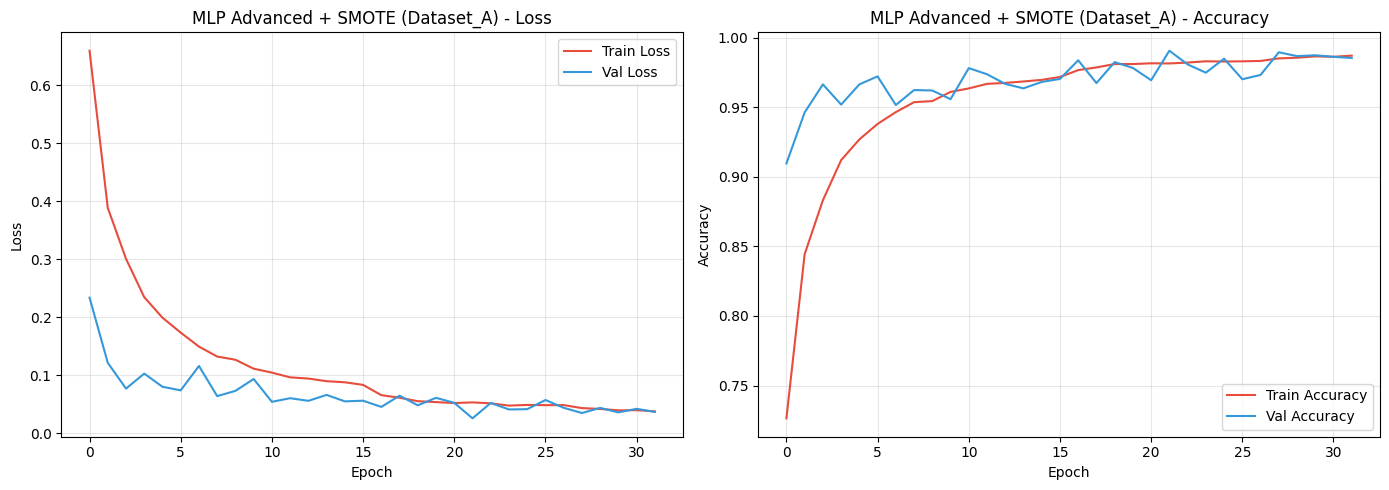

  Acc=0.7417 | F1=0.7288

[10/42] MLP Advanced + RUS (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Classification Report: MLP Advanced + RUS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00      5412
      Netral       0.20      1.00      0.34      1415
     Positif       0.00      0.00      0.00       180

    accuracy                           0.20      7007
   macro avg       0.07      0.33      0.11      7007
weighted avg       0.04      0.20      0.07      7007



C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 

  Saved: results/dataset_kesepakatan/MLP_Advanced/RUS_cm.png


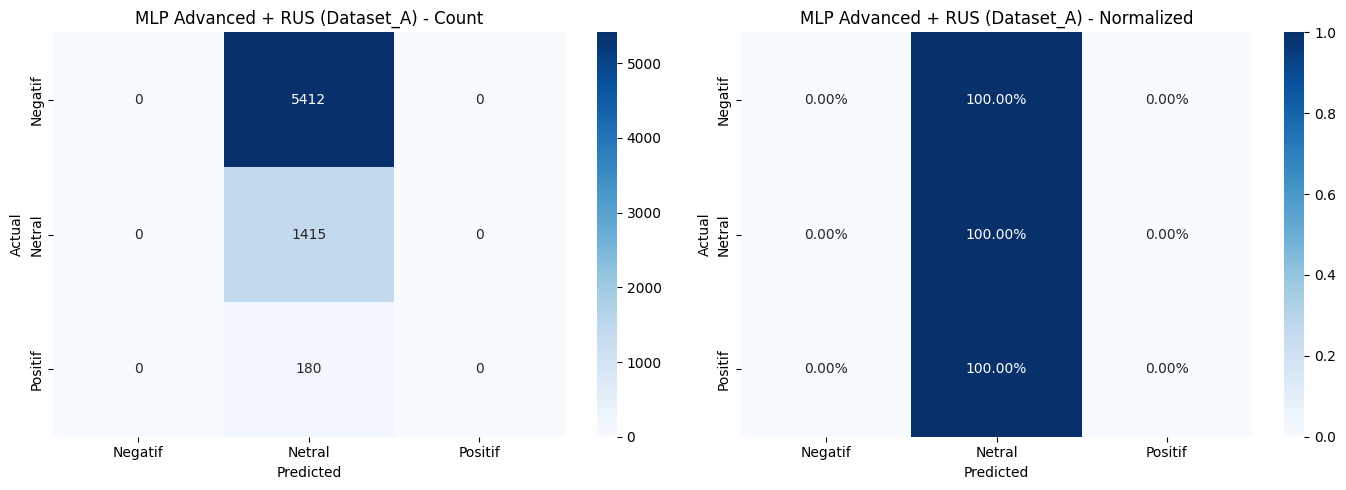

  Saved: results/dataset_kesepakatan/MLP_Advanced/RUS_roc.png


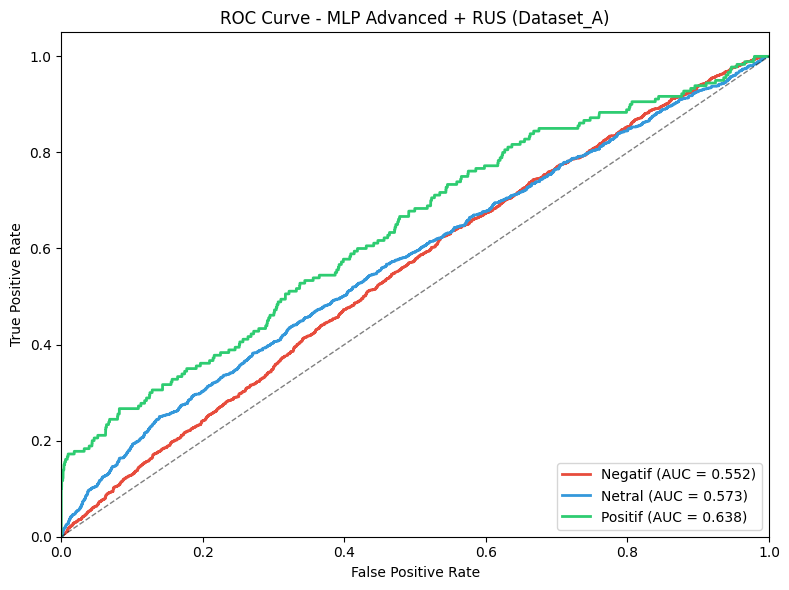

  Saved: results/dataset_kesepakatan/MLP_Advanced/RUS_learning.png


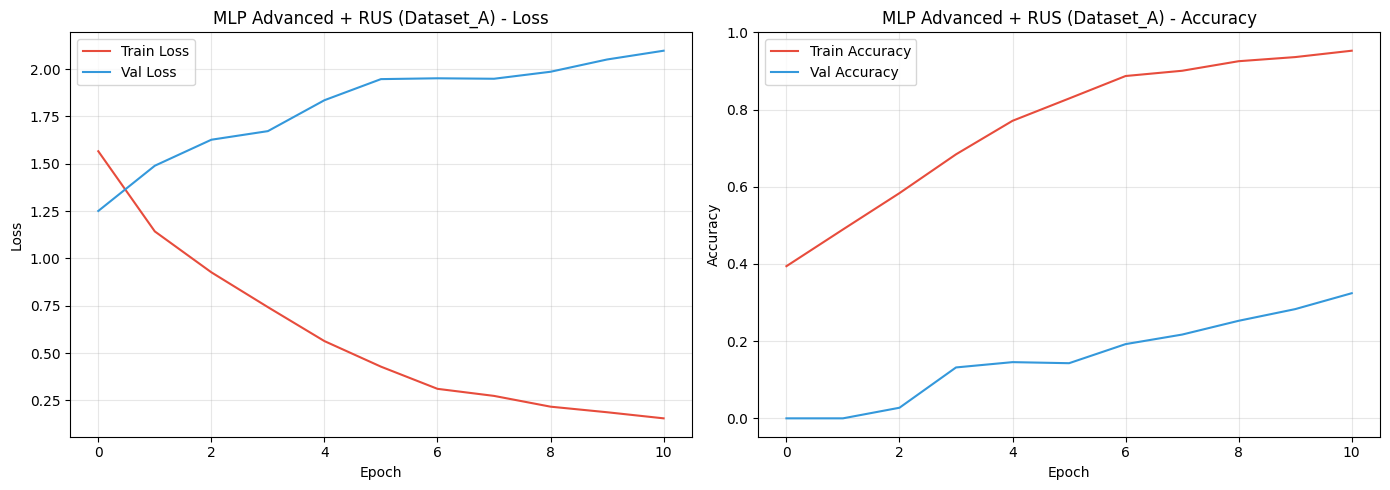

  Acc=0.2019 | F1=0.0679

[11/42] MLP Advanced + SMOTEENN (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Classification Report: MLP Advanced + SMOTEENN (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.85      0.08      0.14      5412
      Netral       0.22      0.82      0.34      1415
     Positif       0.05      0.33      0.09       180

    accuracy                           0.23      7007
   macro avg       0.37      0.41      0.19      7007
weighted avg       0.70      0.23      0.18      7007

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTEENN_cm.png


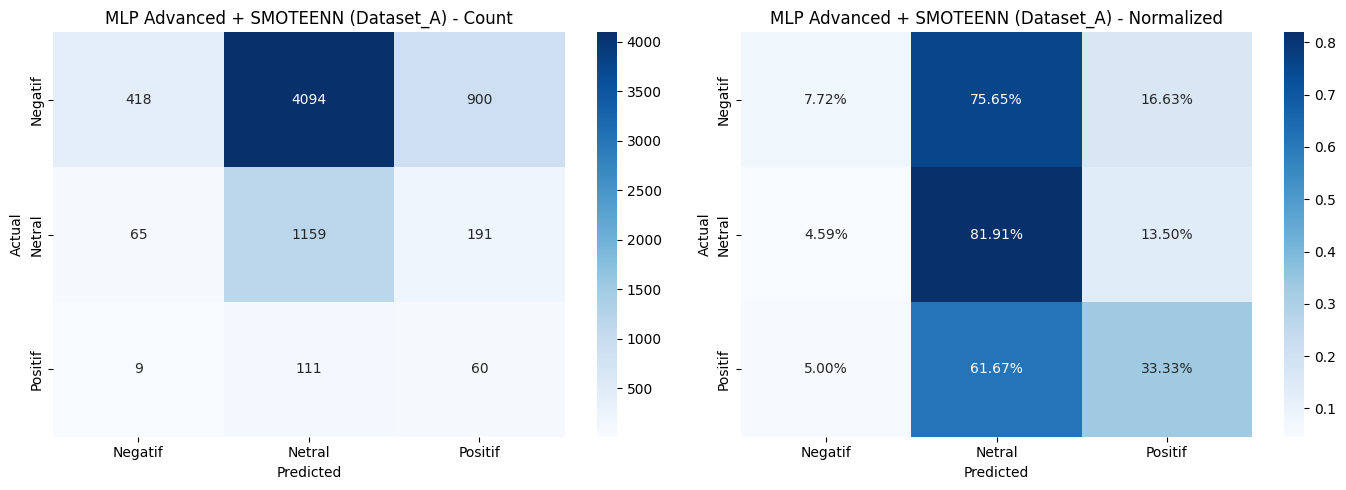

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTEENN_roc.png


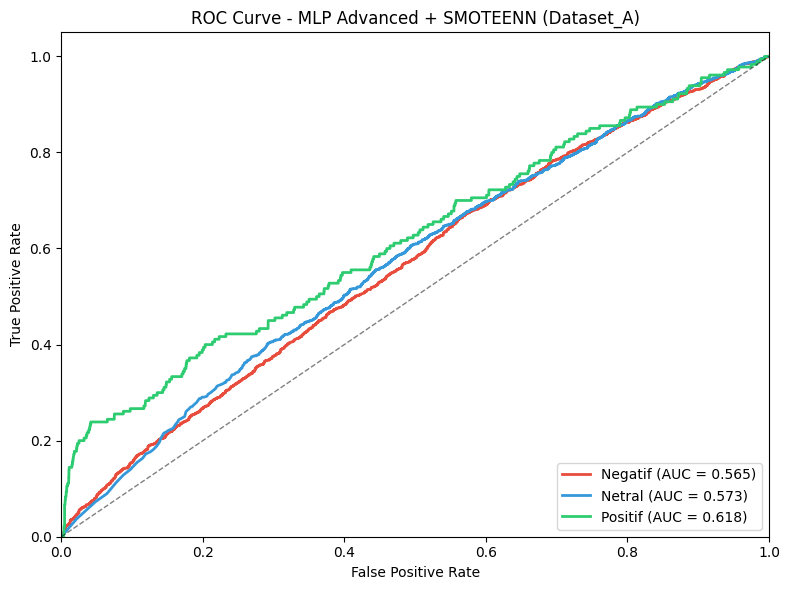

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTEENN_learning.png


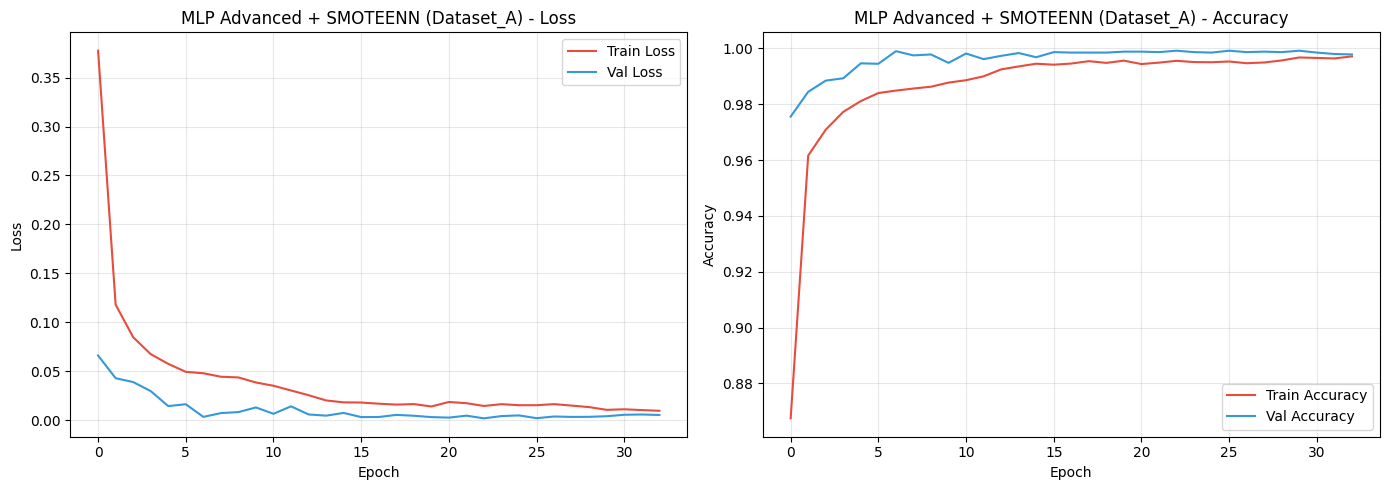

  Acc=0.2336 | F1=0.1807

[12/42] MLP Advanced + SMOTETomek (Dataset_A)
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Classification Report: MLP Advanced + SMOTETomek (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.81      0.89      0.85      5412
      Netral       0.43      0.31      0.36      1415
     Positif       0.26      0.17      0.21       180

    accuracy                           0.75      7007
   macro avg       0.50      0.45      0.47      7007
weighted avg       0.72      0.75      0.73      7007

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTETomek_cm.png


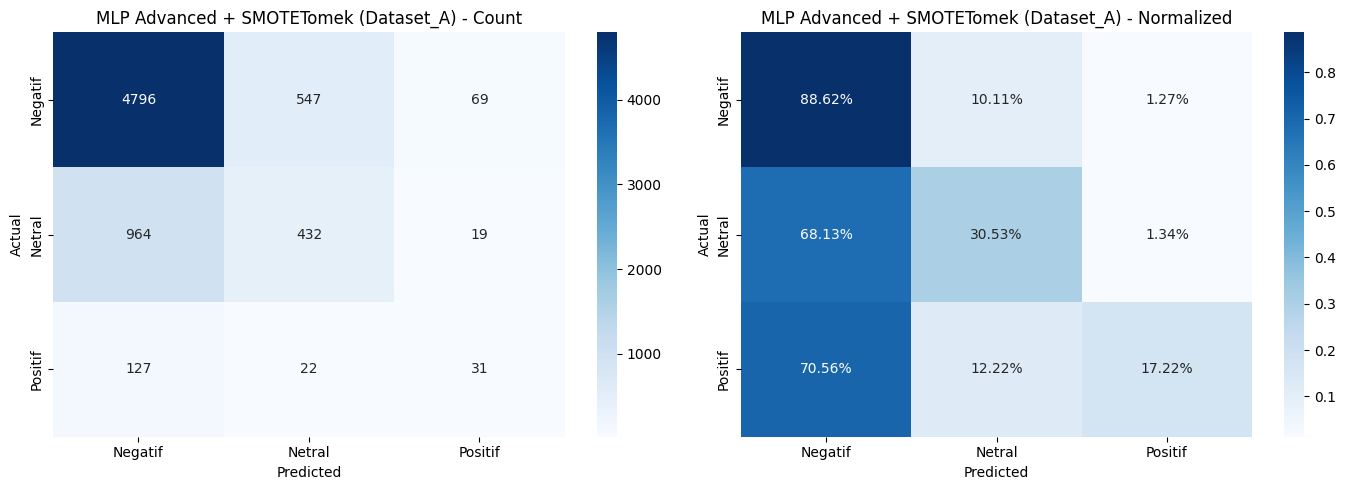

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTETomek_roc.png


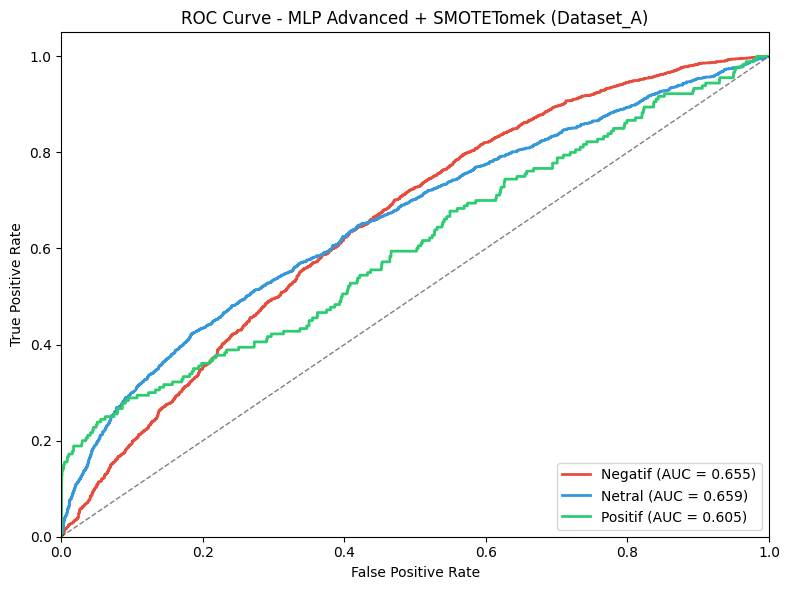

  Saved: results/dataset_kesepakatan/MLP_Advanced/SMOTETomek_learning.png


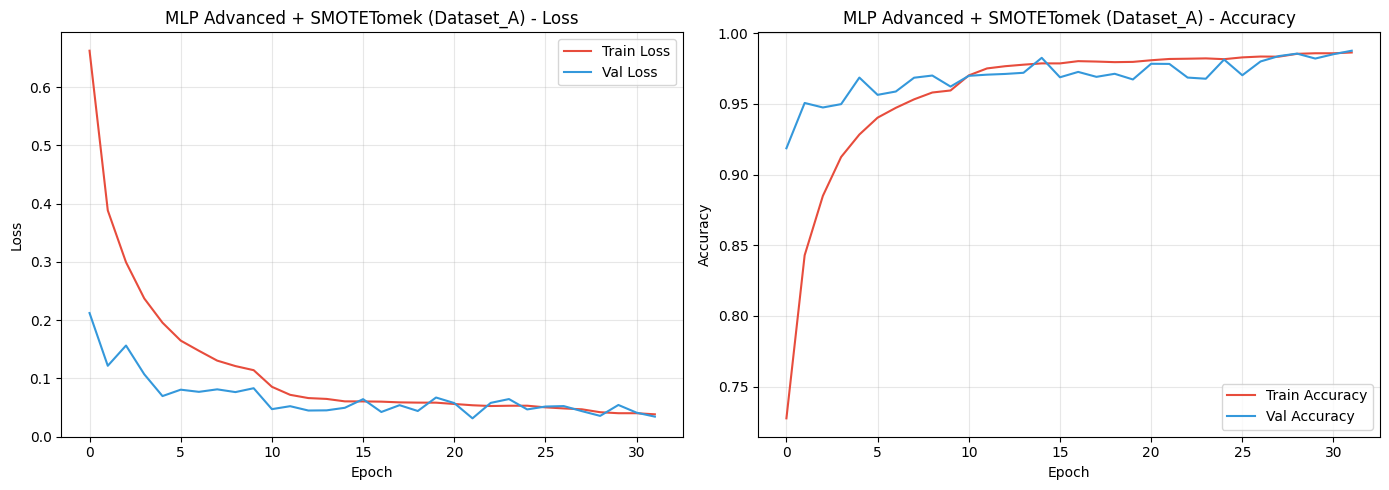

  Acc=0.7505 | F1=0.7332

[13/42] MLP Keras Tuner + No_Balancing (Dataset_A)


C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report: MLP Keras Tuner + No_Balancing (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.81      0.96      0.88      5412
      Netral       0.62      0.21      0.32      1415
     Positif       0.59      0.13      0.22       180

    accuracy                           0.79      7007
   macro avg       0.67      0.44      0.47      7007
weighted avg       0.76      0.79      0.75      7007

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/No_Balancing_cm.png


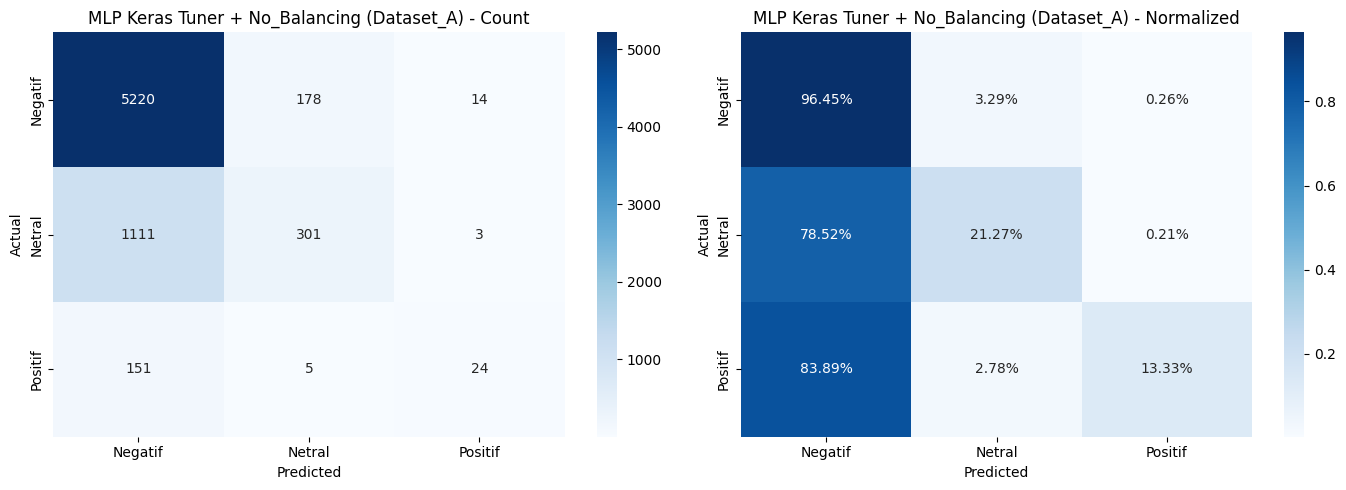

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/No_Balancing_roc.png


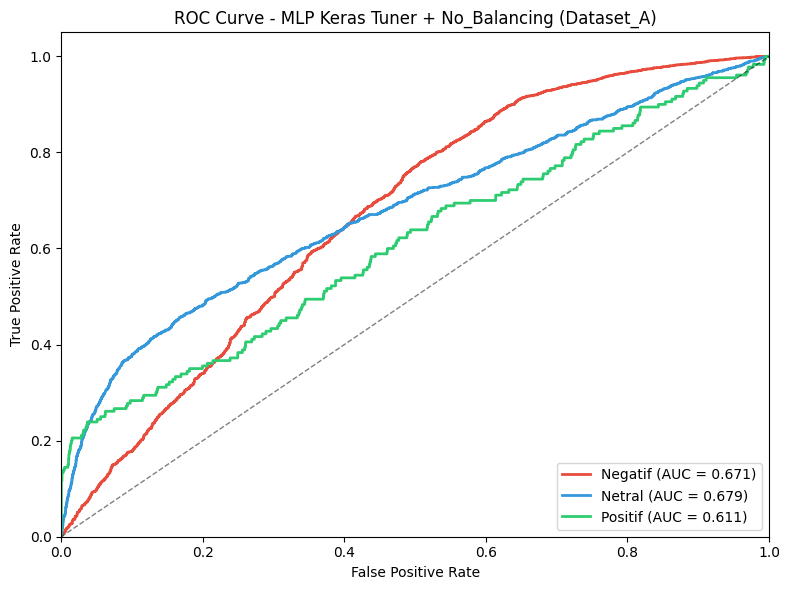

  Acc=0.7914 | F1=0.7475

[14/42] MLP Keras Tuner + ROS (Dataset_A)
  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report: MLP Keras Tuner + ROS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.81      0.85      0.83      5412
      Netral       0.38      0.33      0.35      1415
     Positif       0.19      0.16      0.17       180

    accuracy                           0.73      7007
   macro avg       0.46      0.44      0.45      7007
weighted avg       0.71      0.73      0.72      7007

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/ROS_cm.png


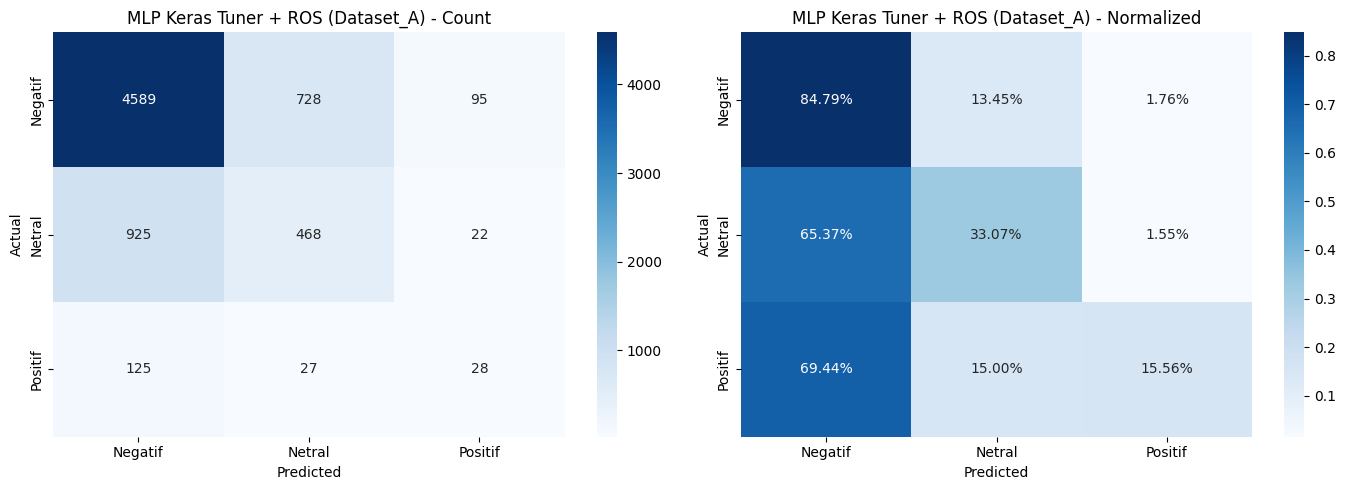

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/ROS_roc.png


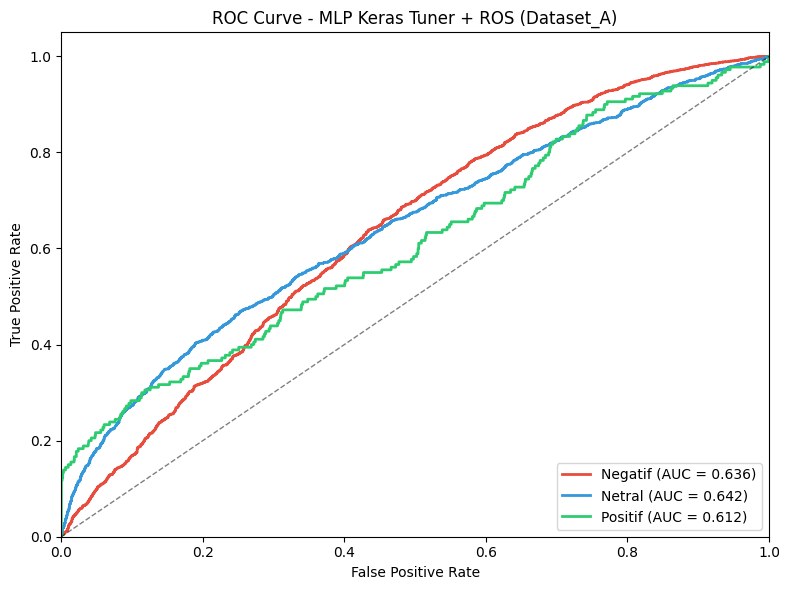

  Acc=0.7257 | F1=0.7175

[15/42] MLP Keras Tuner + SMOTE (Dataset_A)
  1/219 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report: MLP Keras Tuner + SMOTE (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.81      0.88      0.84      5412
      Netral       0.40      0.26      0.31      1415
     Positif       0.15      0.17      0.16       180

    accuracy                           0.73      7007
   macro avg       0.45      0.44      0.44      7007
weighted avg       0.71      0.73      0.72      7007

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/SMOTE_cm.png


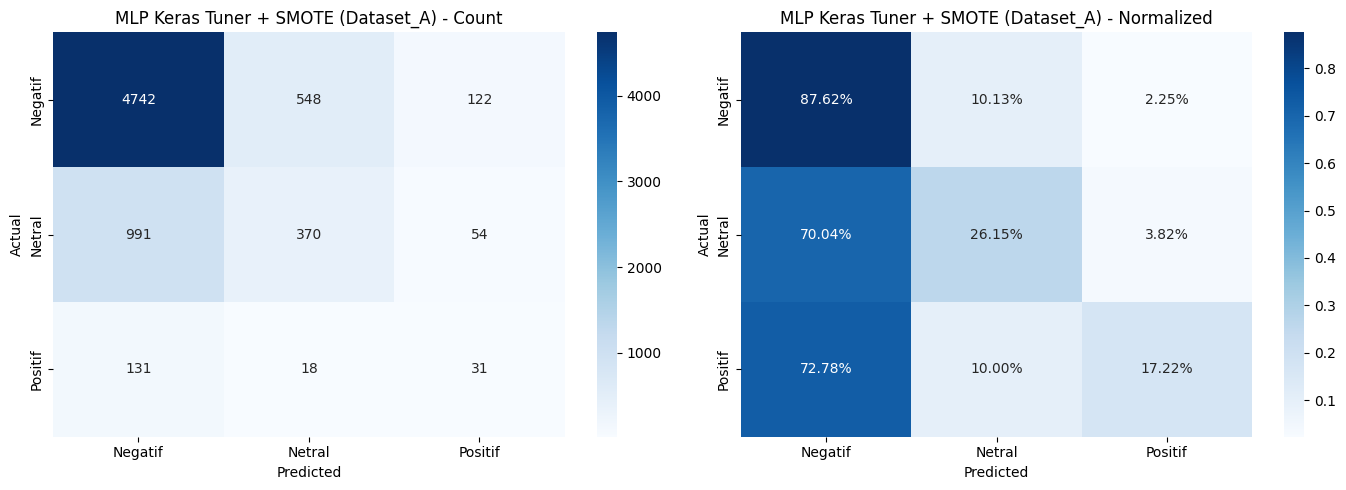

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/SMOTE_roc.png


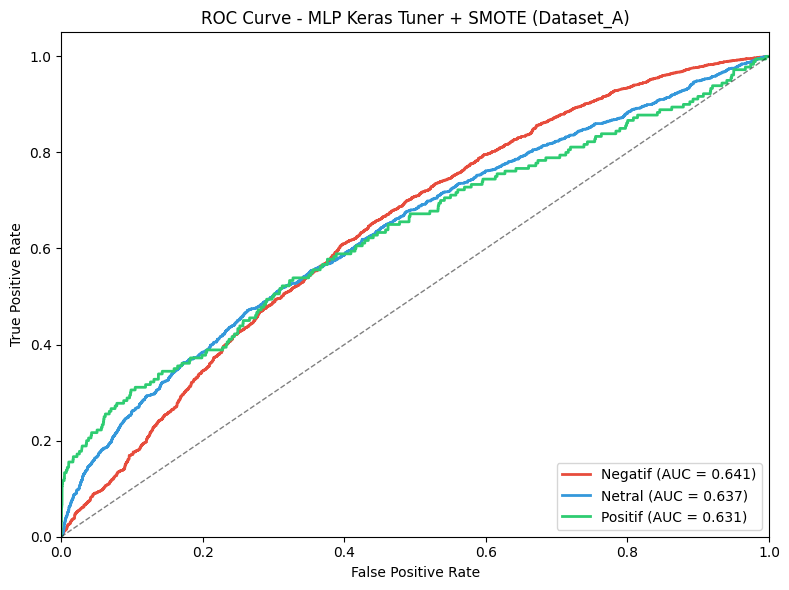

  Acc=0.7340 | F1=0.7173

[16/42] MLP Keras Tuner + RUS (Dataset_A)


C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Classification Report: MLP Keras Tuner + RUS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00      5412
      Netral       0.00      0.00      0.00      1415
     Positif       0.03      1.00      0.05       180

    accuracy                           0.03      7007
   macro avg       0.01      0.33      0.02      7007
weighted avg       0.00      0.03      0.00      7007



C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/RUS_cm.png


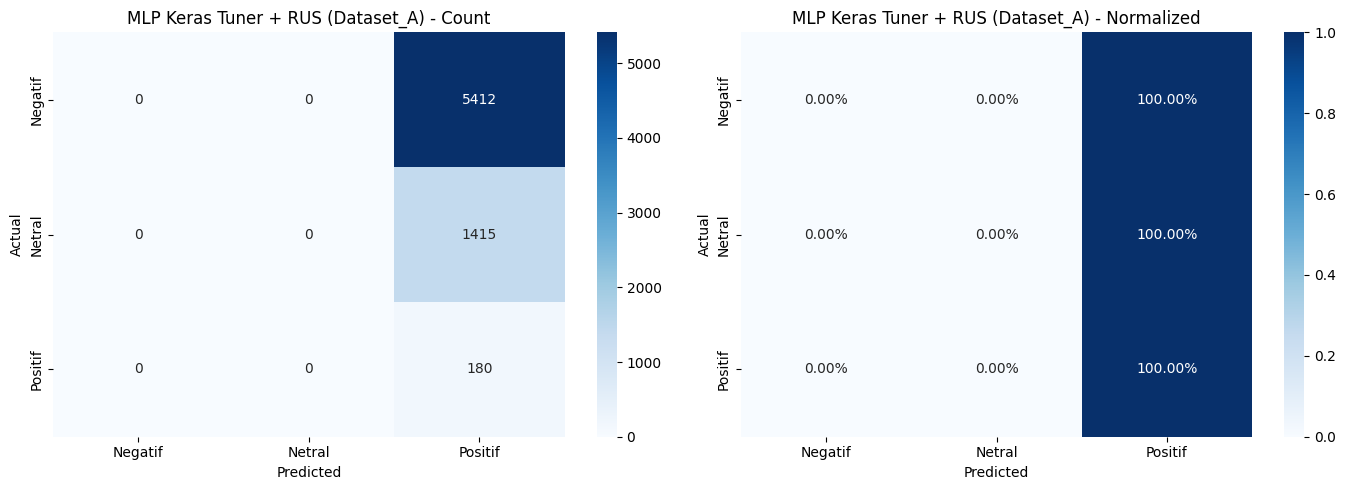

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/RUS_roc.png


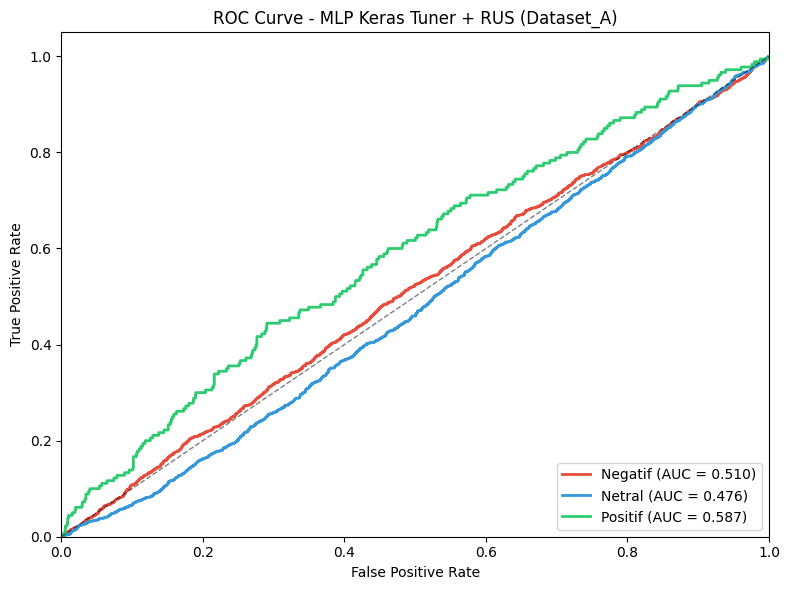

  Acc=0.0257 | F1=0.0013

[17/42] MLP Keras Tuner + SMOTEENN (Dataset_A)
  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Classification Report: MLP Keras Tuner + SMOTEENN (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.87      0.09      0.17      5412
      Netral       0.22      0.82      0.35      1415
     Positif       0.05      0.34      0.09       180

    accuracy                           0.25      7007
   macro avg       0.38      0.42      0.20      7007
weighted avg       0.71      0.25      0.20      7007

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/SMOTEENN_cm.png


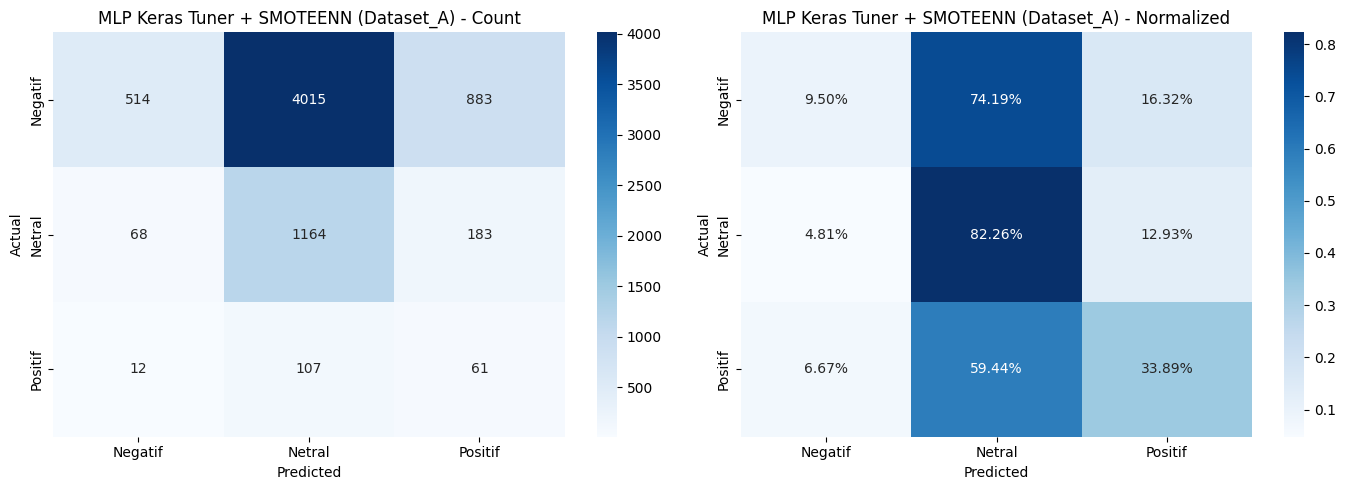

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/SMOTEENN_roc.png


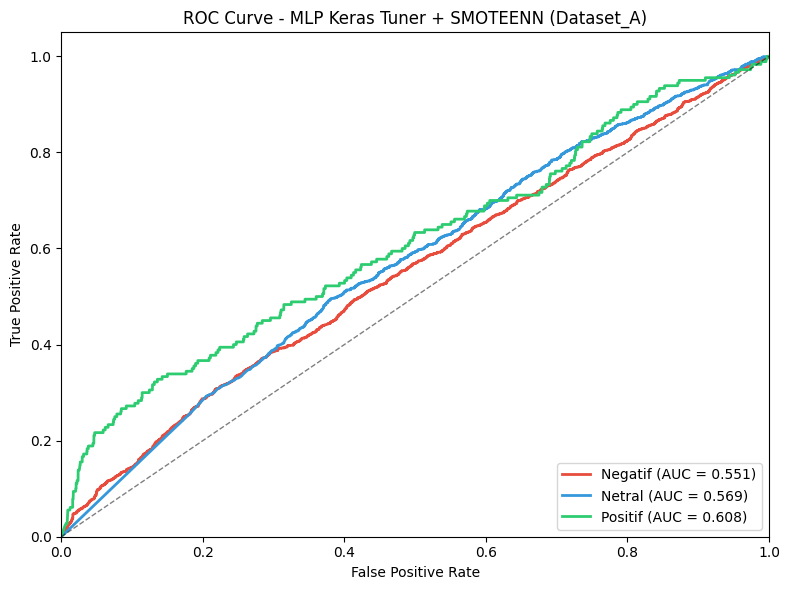

  Acc=0.2482 | F1=0.2048

[18/42] MLP Keras Tuner + SMOTETomek (Dataset_A)
  1/219 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step

C:\Users\Asus\Documents\Kuliah\9\Akhir\Codes\analisis-sentimen-pertamax-oplosan\.env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report: MLP Keras Tuner + SMOTETomek (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.82      0.85      0.83      5412
      Netral       0.40      0.34      0.37      1415
     Positif       0.18      0.17      0.18       180

    accuracy                           0.73      7007
   macro avg       0.47      0.46      0.46      7007
weighted avg       0.72      0.73      0.72      7007

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/SMOTETomek_cm.png


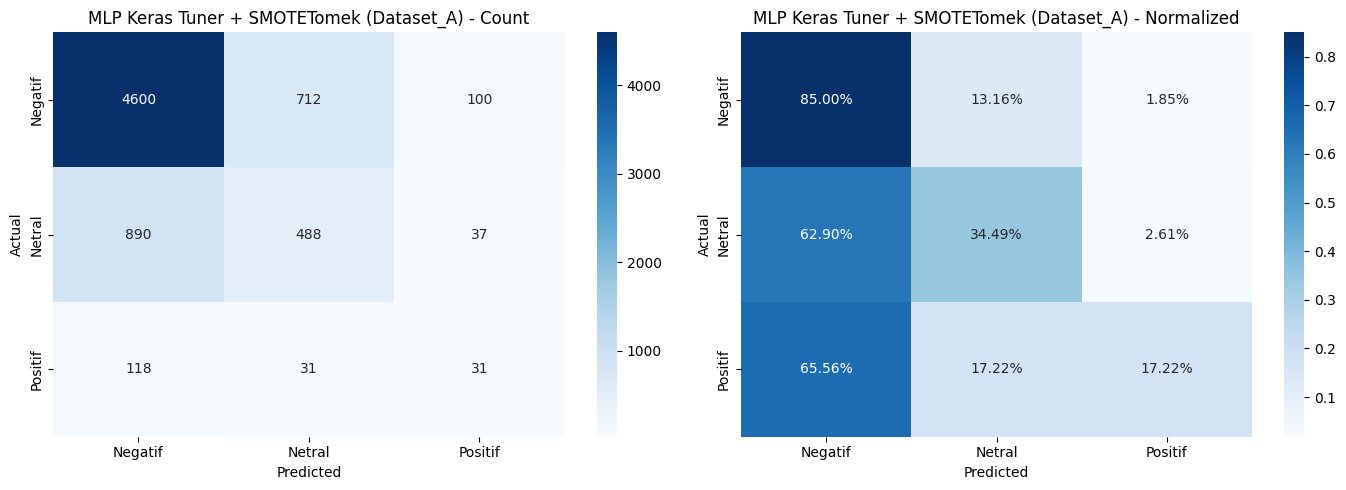

  Saved: results/dataset_kesepakatan/MLP_Keras_Tuner/SMOTETomek_roc.png


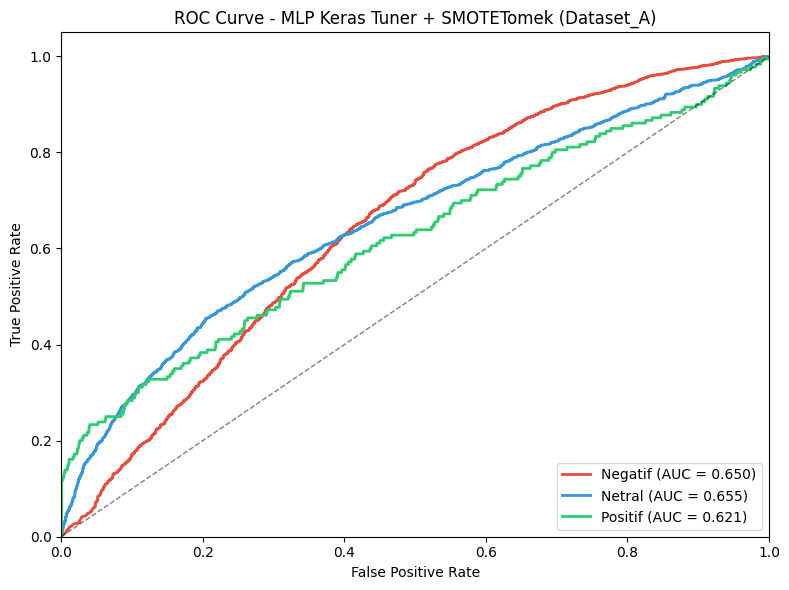

  Acc=0.7306 | F1=0.7239

[19/42] Naive Bayes + No_Balancing (Dataset_A)

--- Classification Report: Naive Bayes + No_Balancing (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.80      0.96      0.88      5412
      Netral       0.62      0.20      0.30      1415
     Positif       0.45      0.13      0.20       180

    accuracy                           0.79      7007
   macro avg       0.62      0.43      0.46      7007
weighted avg       0.76      0.79      0.74      7007

  Saved: results/dataset_kesepakatan/Naive_Bayes/No_Balancing_cm.png


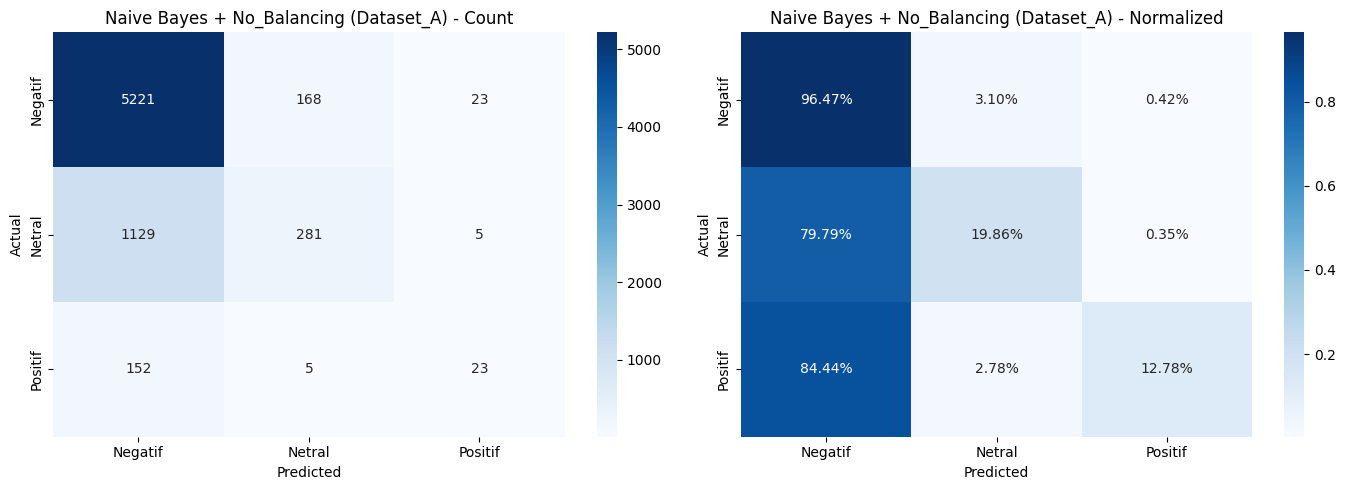

  Saved: results/dataset_kesepakatan/Naive_Bayes/No_Balancing_roc.png


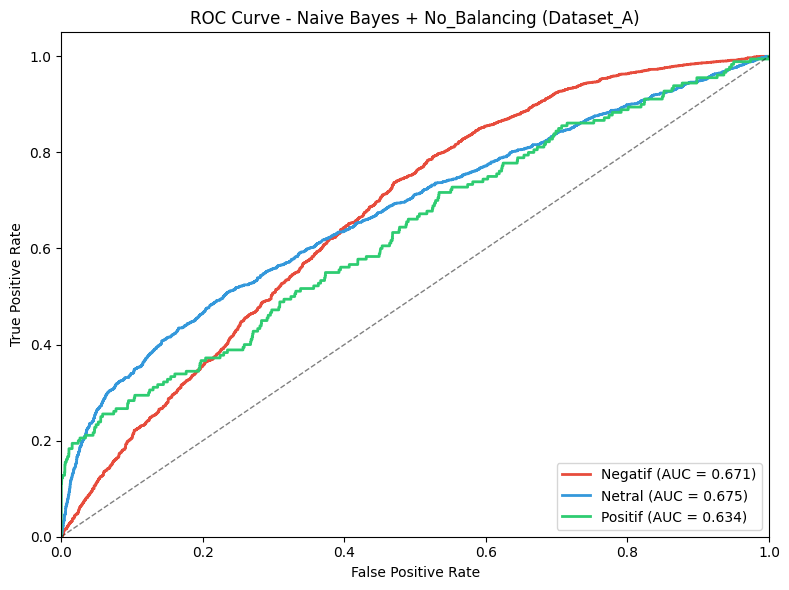

  Acc=0.7885 | F1=0.7428

[20/42] Naive Bayes + ROS (Dataset_A)

--- Classification Report: Naive Bayes + ROS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.84      0.72      0.77      5412
      Netral       0.36      0.47      0.40      1415
     Positif       0.09      0.27      0.14       180

    accuracy                           0.65      7007
   macro avg       0.43      0.48      0.44      7007
weighted avg       0.72      0.65      0.68      7007

  Saved: results/dataset_kesepakatan/Naive_Bayes/ROS_cm.png


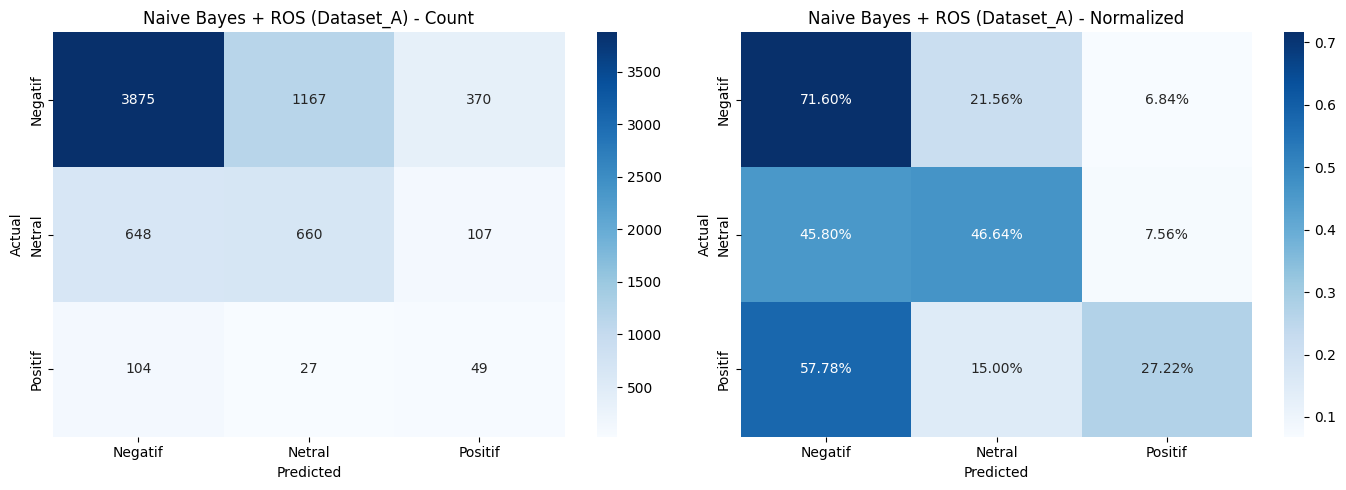

  Saved: results/dataset_kesepakatan/Naive_Bayes/ROS_roc.png


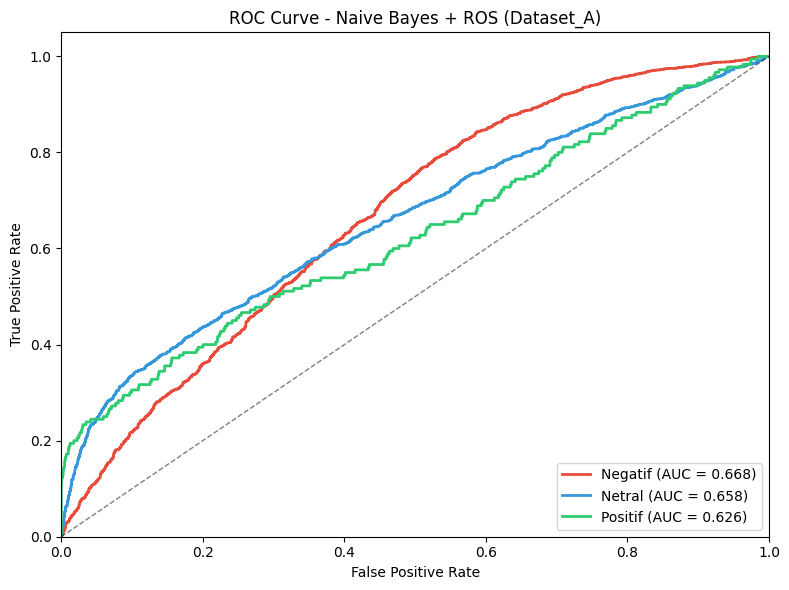

  Acc=0.6542 | F1=0.6814

[21/42] Naive Bayes + SMOTE (Dataset_A)

--- Classification Report: Naive Bayes + SMOTE (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.84      0.74      0.79      5412
      Netral       0.37      0.46      0.41      1415
     Positif       0.10      0.26      0.14       180

    accuracy                           0.67      7007
   macro avg       0.44      0.49      0.45      7007
weighted avg       0.72      0.67      0.69      7007

  Saved: results/dataset_kesepakatan/Naive_Bayes/SMOTE_cm.png


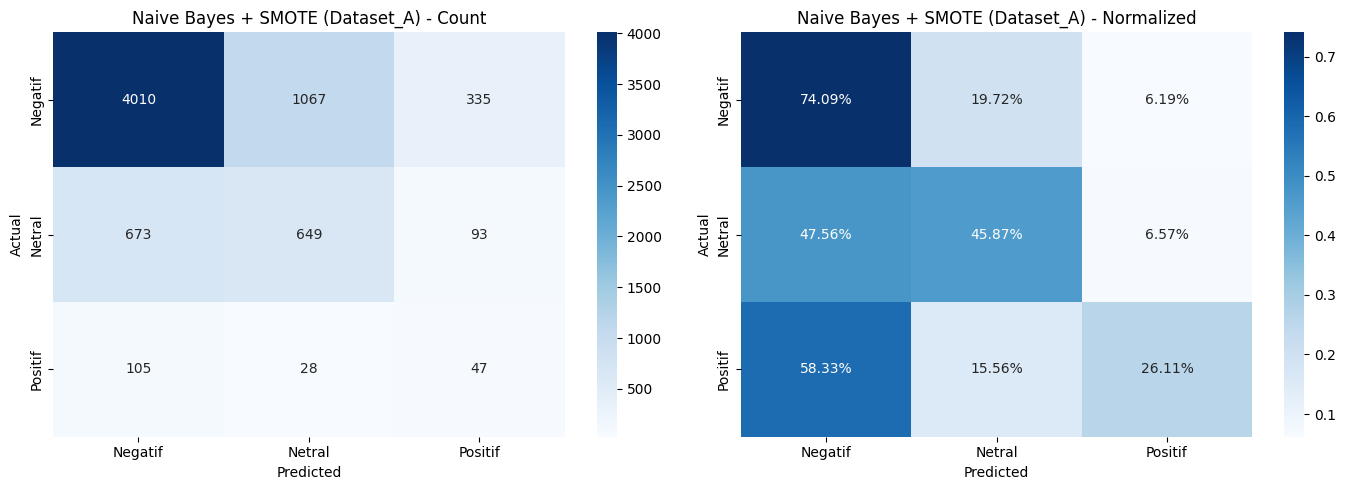

  Saved: results/dataset_kesepakatan/Naive_Bayes/SMOTE_roc.png


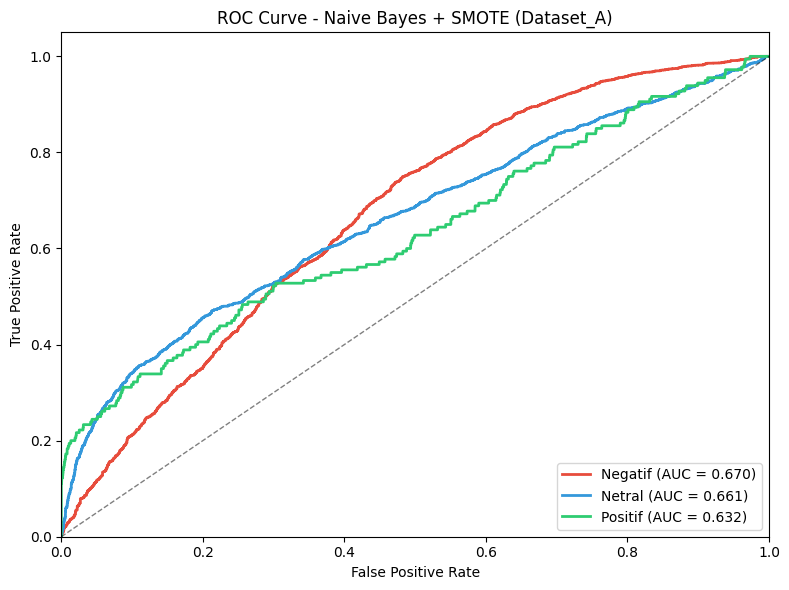

  Acc=0.6716 | F1=0.6940

[22/42] Naive Bayes + RUS (Dataset_A)

--- Classification Report: Naive Bayes + RUS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.57      0.68      5412
      Netral       0.32      0.47      0.38      1415
     Positif       0.06      0.41      0.10       180

    accuracy                           0.54      7007
   macro avg       0.40      0.48      0.39      7007
weighted avg       0.71      0.54      0.60      7007

  Saved: results/dataset_kesepakatan/Naive_Bayes/RUS_cm.png


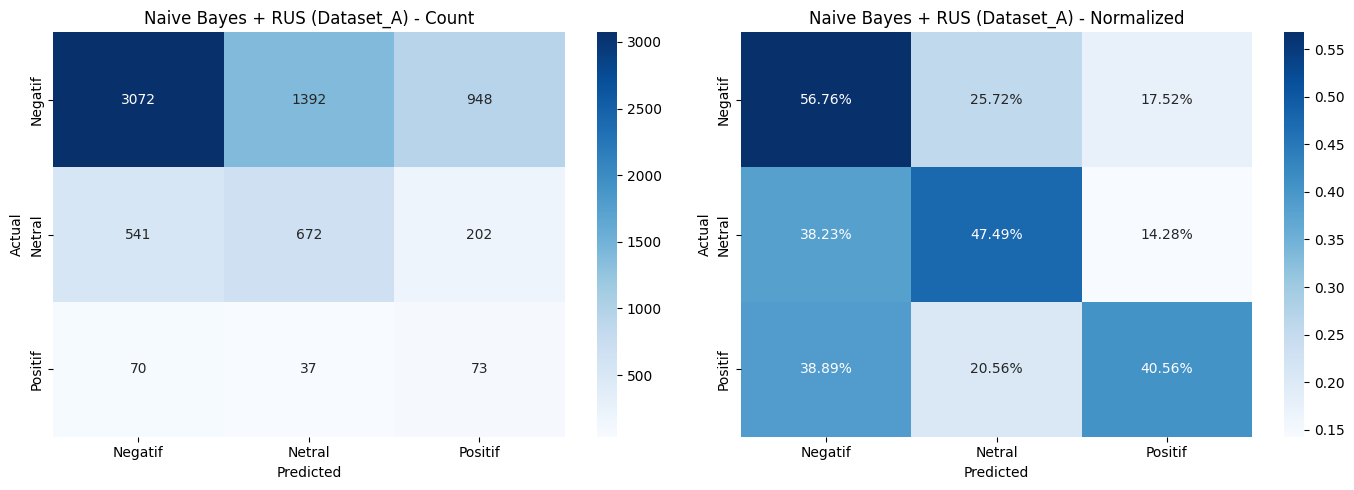

  Saved: results/dataset_kesepakatan/Naive_Bayes/RUS_roc.png


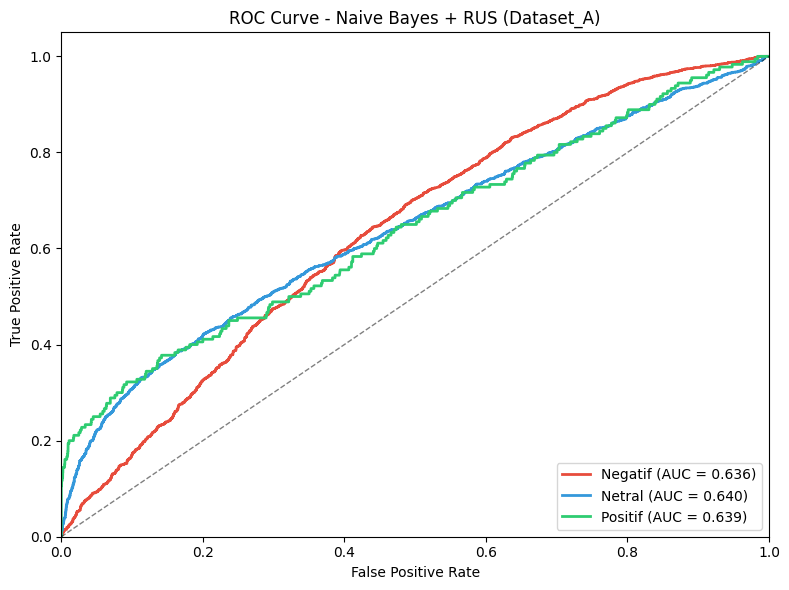

  Acc=0.5447 | F1=0.6016

[23/42] Naive Bayes + SMOTEENN (Dataset_A)

--- Classification Report: Naive Bayes + SMOTEENN (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.89      0.02      0.04      5412
      Netral       0.21      0.83      0.34      1415
     Positif       0.05      0.41      0.10       180

    accuracy                           0.20      7007
   macro avg       0.39      0.42      0.16      7007
weighted avg       0.73      0.20      0.11      7007

  Saved: results/dataset_kesepakatan/Naive_Bayes/SMOTEENN_cm.png


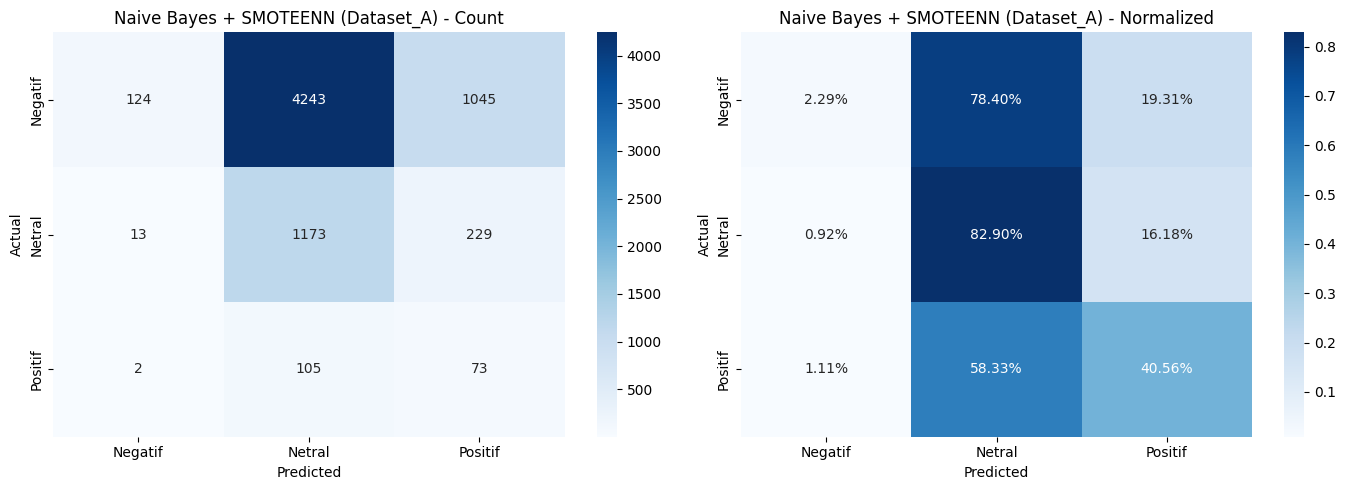

  Saved: results/dataset_kesepakatan/Naive_Bayes/SMOTEENN_roc.png


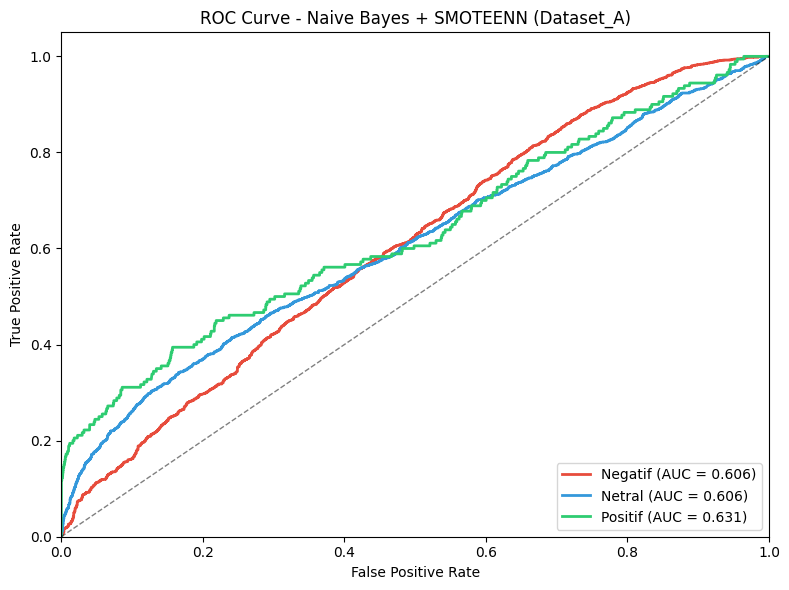

  Acc=0.1955 | F1=0.1053

[24/42] Naive Bayes + SMOTETomek (Dataset_A)

--- Classification Report: Naive Bayes + SMOTETomek (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.84      0.74      0.79      5412
      Netral       0.37      0.46      0.41      1415
     Positif       0.09      0.26      0.14       180

    accuracy                           0.67      7007
   macro avg       0.44      0.49      0.45      7007
weighted avg       0.73      0.67      0.69      7007

  Saved: results/dataset_kesepakatan/Naive_Bayes/SMOTETomek_cm.png


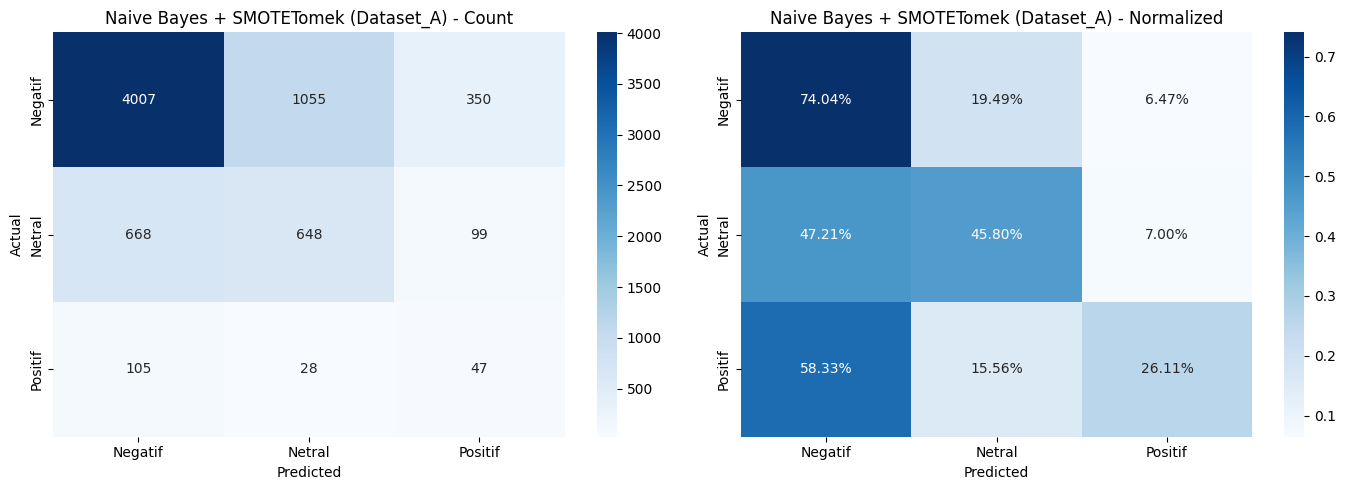

  Saved: results/dataset_kesepakatan/Naive_Bayes/SMOTETomek_roc.png


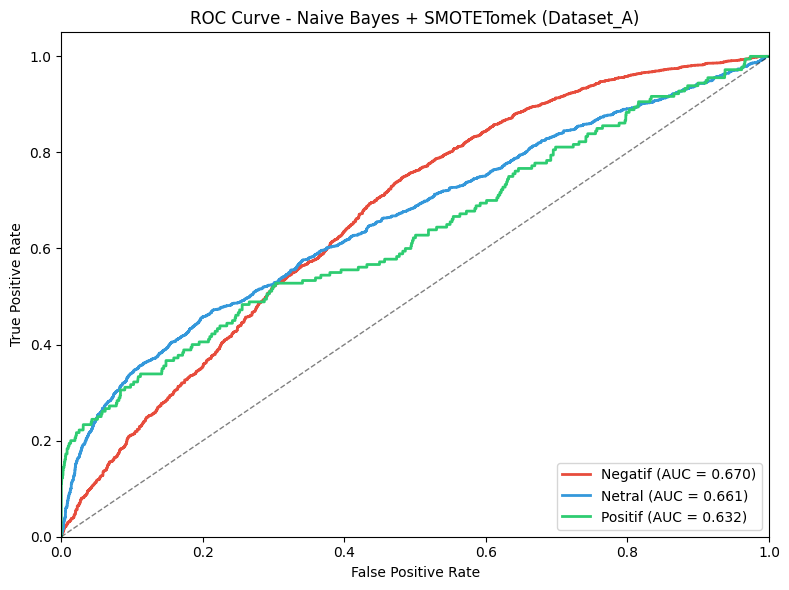

  Acc=0.6710 | F1=0.6941

[25/42] SVM + No_Balancing (Dataset_A)

--- Classification Report: SVM + No_Balancing (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.80      0.97      0.88      5412
      Netral       0.65      0.20      0.31      1415
     Positif       0.81      0.12      0.20       180

    accuracy                           0.79      7007
   macro avg       0.75      0.43      0.46      7007
weighted avg       0.77      0.79      0.75      7007

  Saved: results/dataset_kesepakatan/SVM/No_Balancing_cm.png


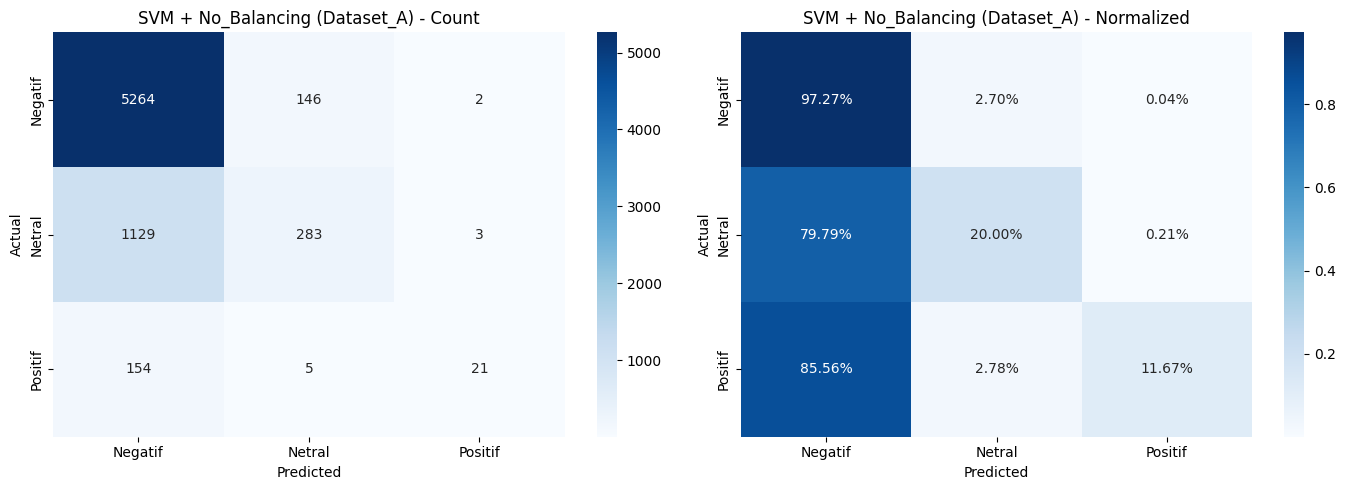

  Saved: results/dataset_kesepakatan/SVM/No_Balancing_roc.png


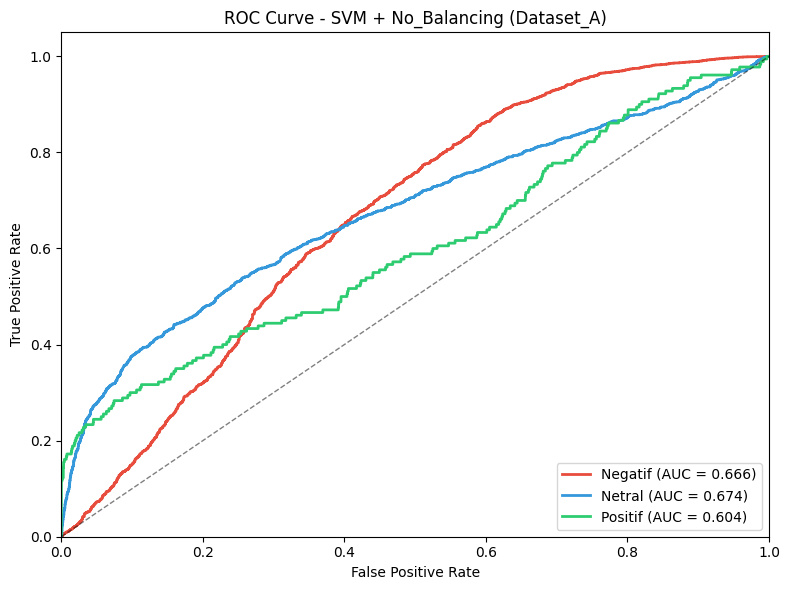

  Acc=0.7946 | F1=0.7470

[26/42] SVM + ROS (Dataset_A)

--- Classification Report: SVM + ROS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.84      0.70      0.76      5412
      Netral       0.34      0.49      0.40      1415
     Positif       0.09      0.23      0.13       180

    accuracy                           0.64      7007
   macro avg       0.42      0.47      0.43      7007
weighted avg       0.72      0.64      0.67      7007

  Saved: results/dataset_kesepakatan/SVM/ROS_cm.png


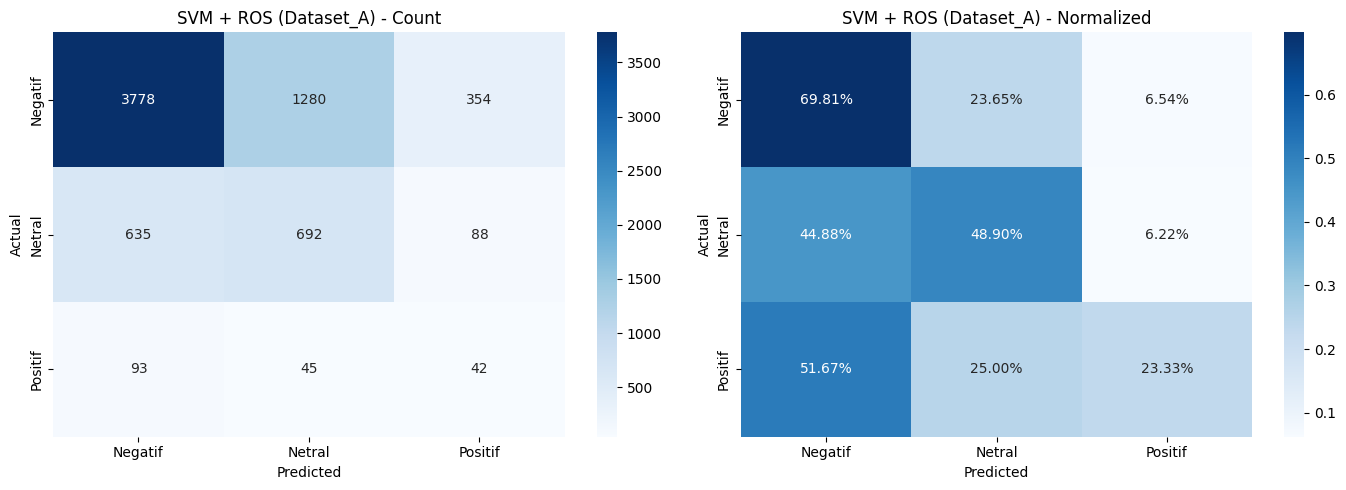

  Saved: results/dataset_kesepakatan/SVM/ROS_roc.png


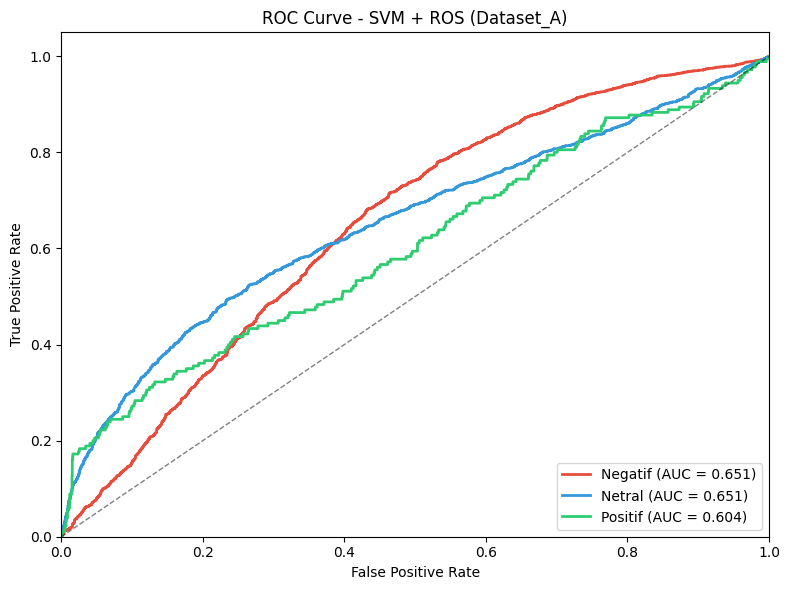

  Acc=0.6439 | F1=0.6731

[27/42] SVM + SMOTE (Dataset_A)

--- Classification Report: SVM + SMOTE (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.79      0.81      5412
      Netral       0.43      0.39      0.41      1415
     Positif       0.08      0.26      0.12       180

    accuracy                           0.70      7007
   macro avg       0.45      0.48      0.45      7007
weighted avg       0.73      0.70      0.71      7007

  Saved: results/dataset_kesepakatan/SVM/SMOTE_cm.png


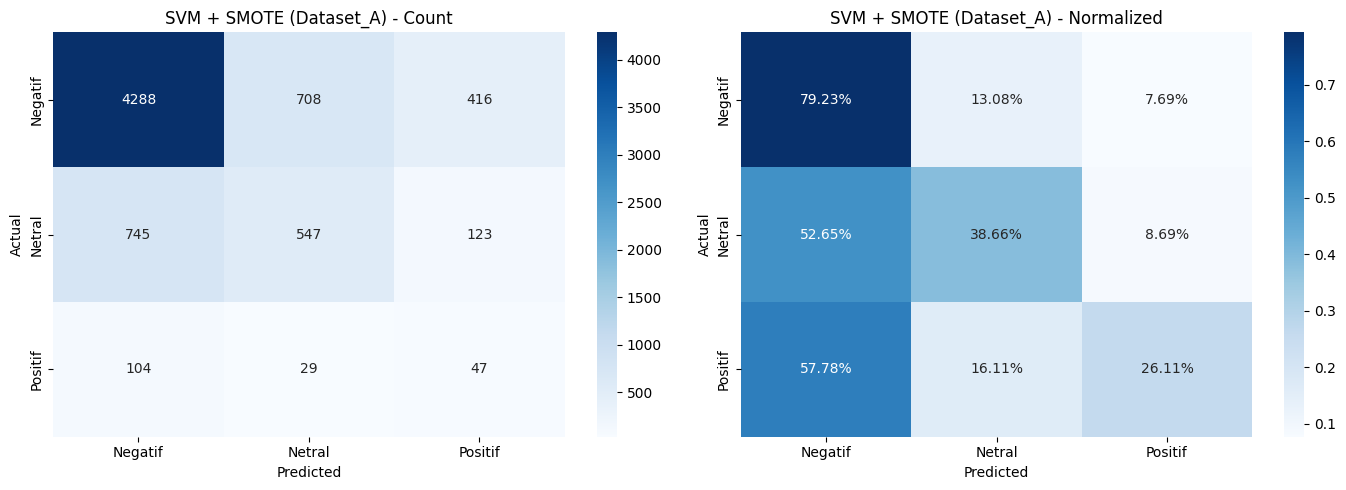

  Saved: results/dataset_kesepakatan/SVM/SMOTE_roc.png


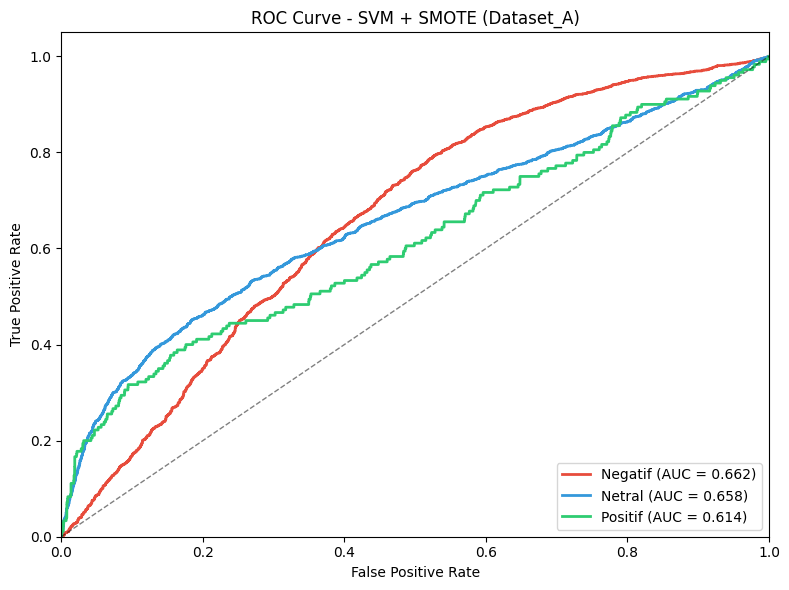

  Acc=0.6967 | F1=0.7129

[28/42] SVM + RUS (Dataset_A)

--- Classification Report: SVM + RUS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.84      0.52      0.64      5412
      Netral       0.33      0.48      0.39      1415
     Positif       0.05      0.43      0.09       180

    accuracy                           0.51      7007
   macro avg       0.41      0.48      0.37      7007
weighted avg       0.71      0.51      0.58      7007

  Saved: results/dataset_kesepakatan/SVM/RUS_cm.png


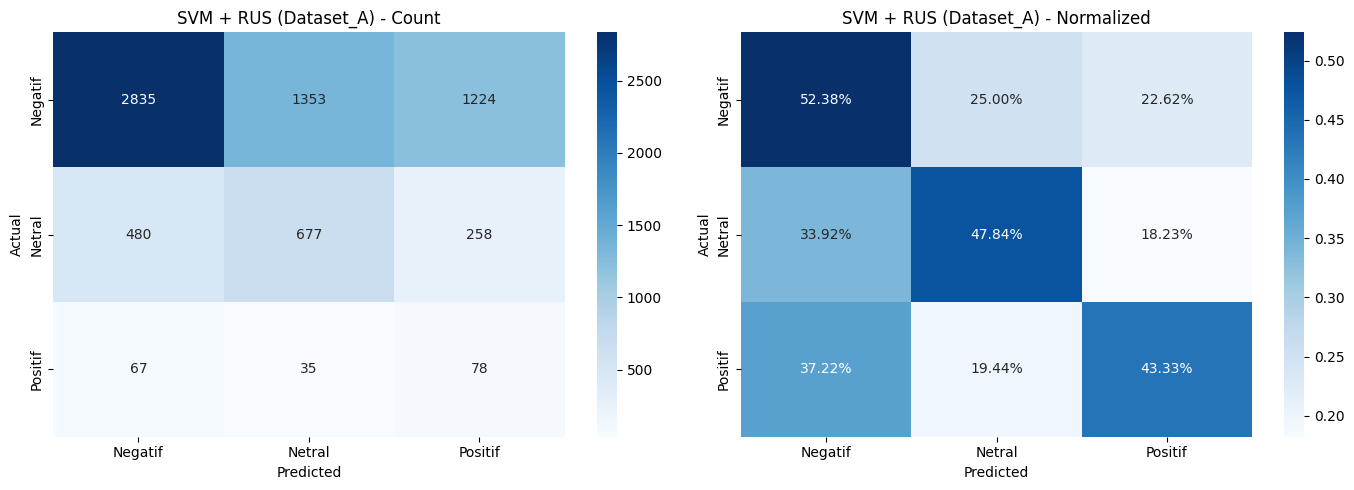

  Saved: results/dataset_kesepakatan/SVM/RUS_roc.png


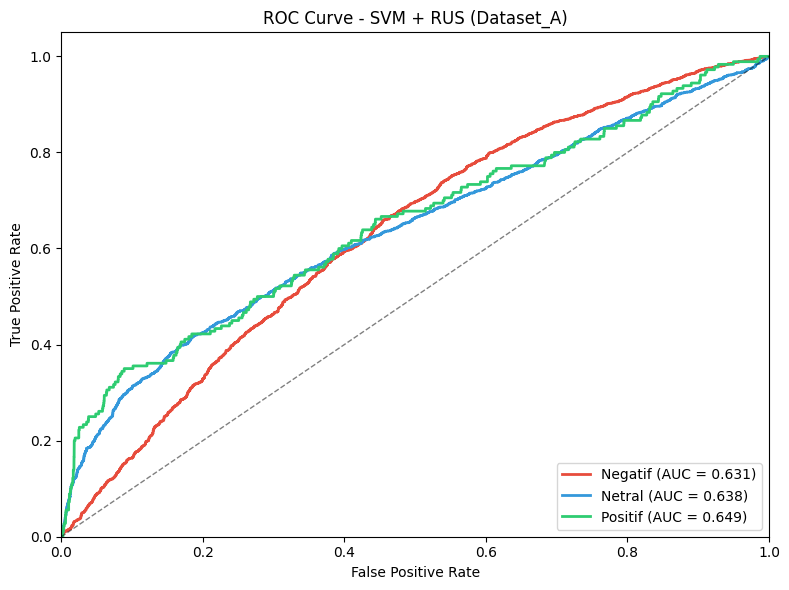

  Acc=0.5123 | F1=0.5789

[29/42] SVM + SMOTEENN (Dataset_A)

--- Classification Report: SVM + SMOTEENN (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.87      0.08      0.14      5412
      Netral       0.22      0.80      0.34      1415
     Positif       0.05      0.38      0.09       180

    accuracy                           0.23      7007
   macro avg       0.38      0.42      0.19      7007
weighted avg       0.72      0.23      0.18      7007

  Saved: results/dataset_kesepakatan/SVM/SMOTEENN_cm.png


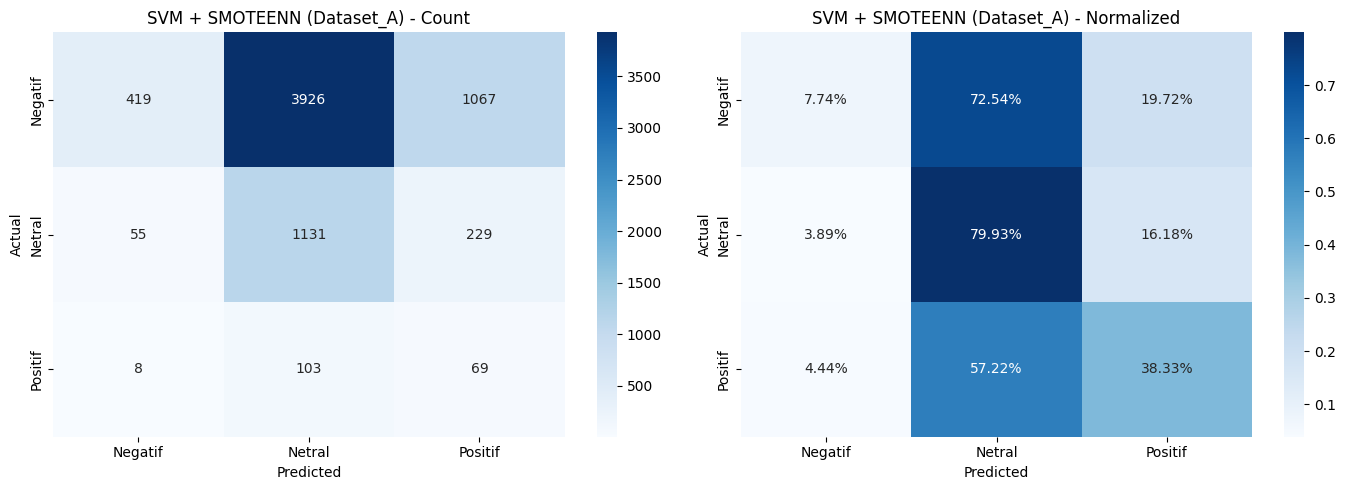

  Saved: results/dataset_kesepakatan/SVM/SMOTEENN_roc.png


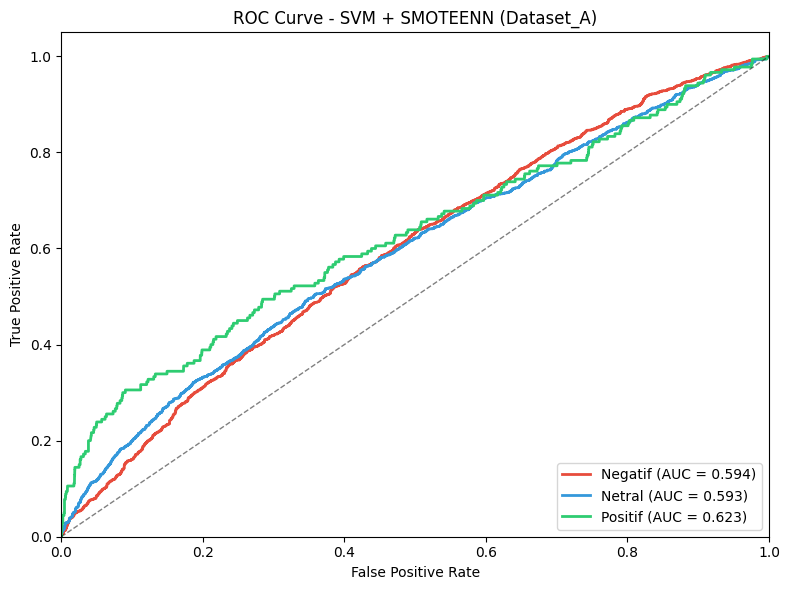

  Acc=0.2311 | F1=0.1816

[30/42] SVM + SMOTETomek (Dataset_A)

--- Classification Report: SVM + SMOTETomek (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.79      0.81      5412
      Netral       0.42      0.38      0.40      1415
     Positif       0.08      0.26      0.12       180

    accuracy                           0.70      7007
   macro avg       0.45      0.48      0.45      7007
weighted avg       0.73      0.70      0.71      7007

  Saved: results/dataset_kesepakatan/SVM/SMOTETomek_cm.png


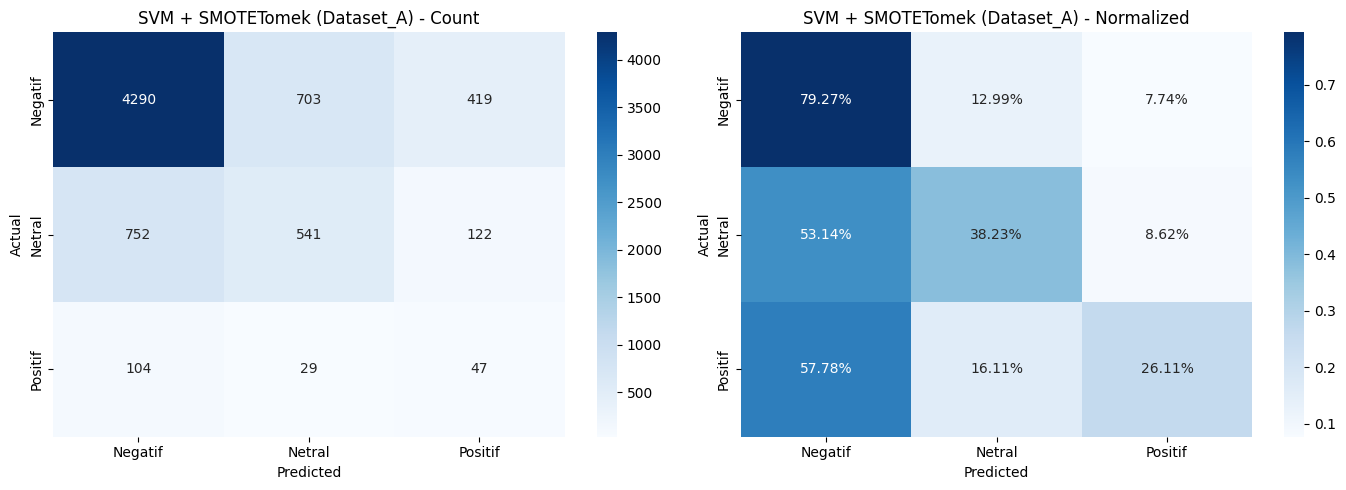

  Saved: results/dataset_kesepakatan/SVM/SMOTETomek_roc.png


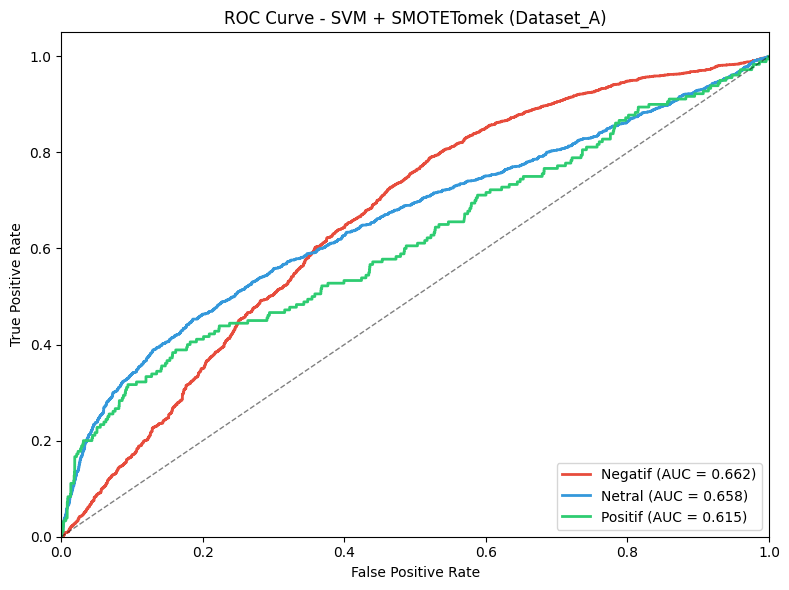

  Acc=0.6962 | F1=0.7121

[31/42] Random Forest + No_Balancing (Dataset_A)

--- Classification Report: Random Forest + No_Balancing (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.82      0.96      0.88      5412
      Netral       0.64      0.29      0.40      1415
     Positif       0.75      0.13      0.23       180

    accuracy                           0.80      7007
   macro avg       0.74      0.46      0.50      7007
weighted avg       0.78      0.80      0.77      7007

  Saved: results/dataset_kesepakatan/Random_Forest/No_Balancing_cm.png


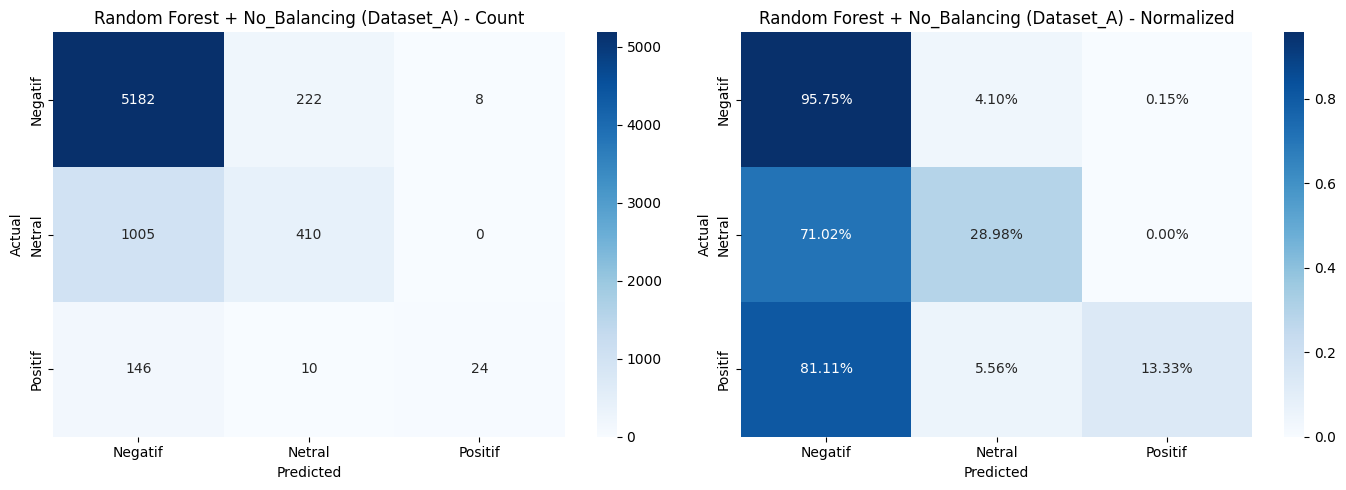

  Saved: results/dataset_kesepakatan/Random_Forest/No_Balancing_roc.png


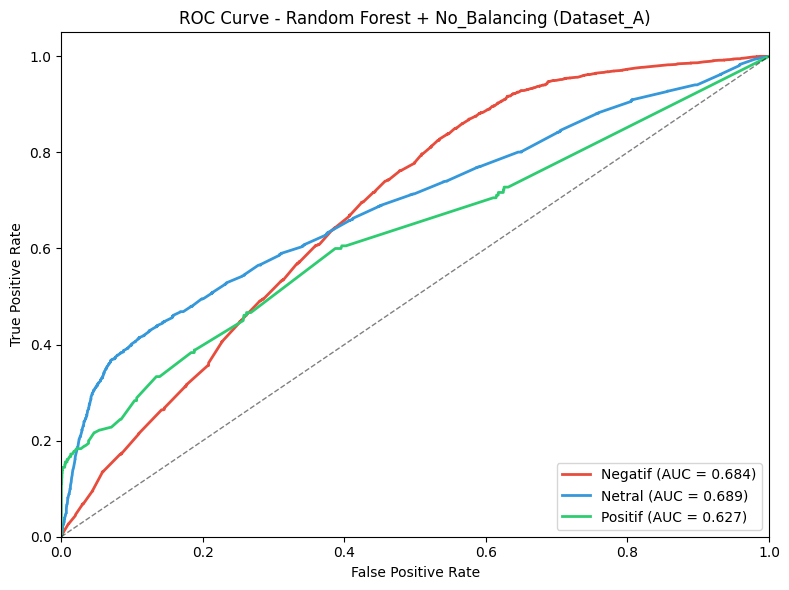

  Acc=0.8015 | F1=0.7679

[32/42] Random Forest + ROS (Dataset_A)

--- Classification Report: Random Forest + ROS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.93      0.87      5412
      Netral       0.57      0.35      0.43      1415
     Positif       0.37      0.14      0.20       180

    accuracy                           0.79      7007
   macro avg       0.59      0.47      0.50      7007
weighted avg       0.76      0.79      0.77      7007

  Saved: results/dataset_kesepakatan/Random_Forest/ROS_cm.png


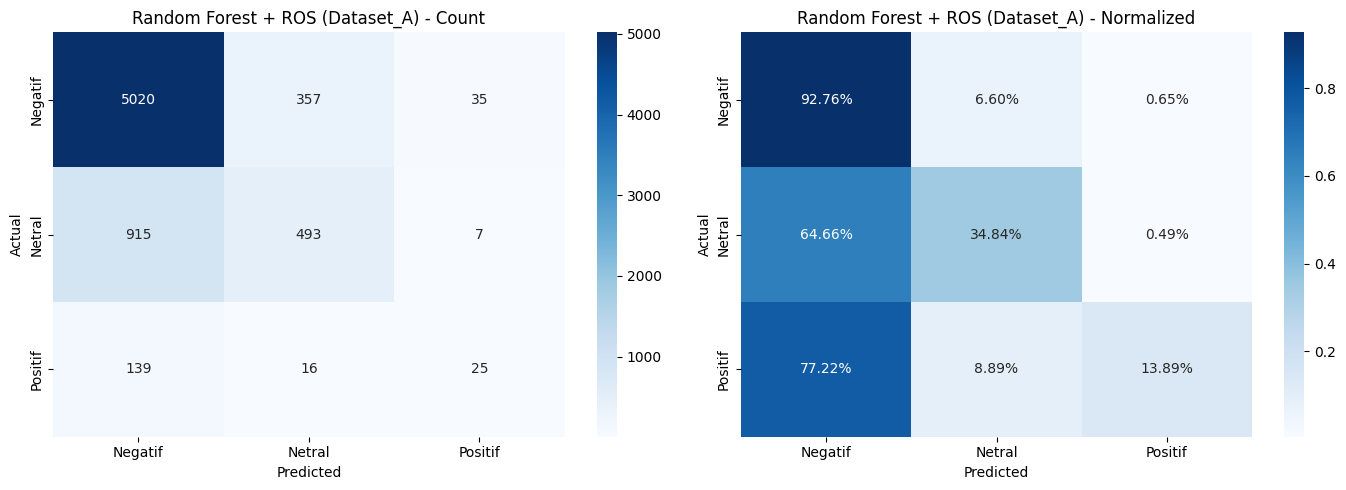

  Saved: results/dataset_kesepakatan/Random_Forest/ROS_roc.png


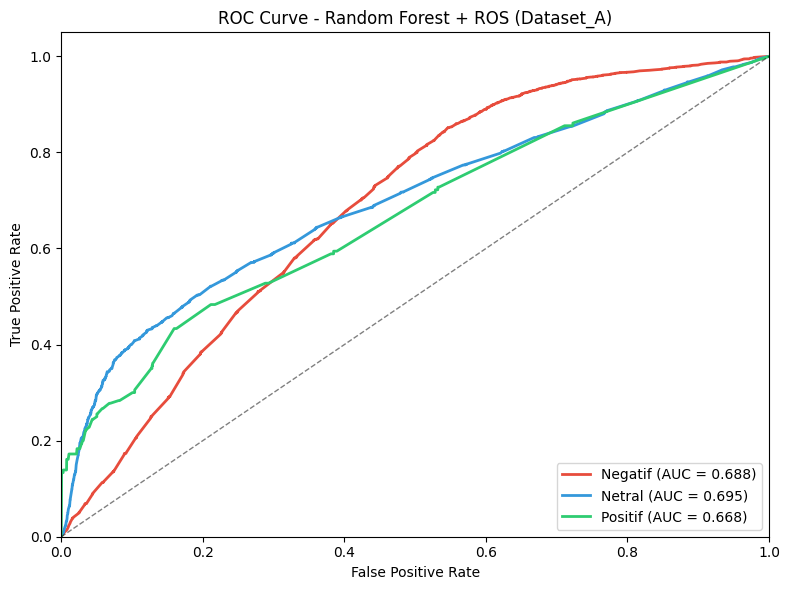

  Acc=0.7904 | F1=0.7676

[33/42] Random Forest + SMOTE (Dataset_A)

--- Classification Report: Random Forest + SMOTE (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.91      0.87      5412
      Netral       0.53      0.36      0.43      1415
     Positif       0.31      0.17      0.22       180

    accuracy                           0.78      7007
   macro avg       0.55      0.48      0.50      7007
weighted avg       0.75      0.78      0.76      7007

  Saved: results/dataset_kesepakatan/Random_Forest/SMOTE_cm.png


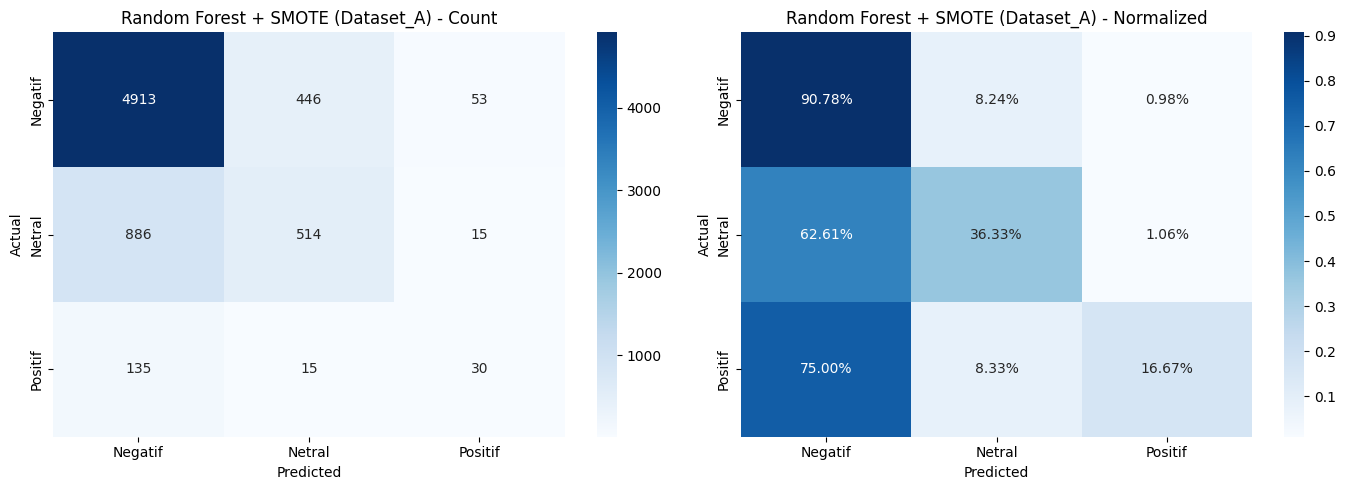

  Saved: results/dataset_kesepakatan/Random_Forest/SMOTE_roc.png


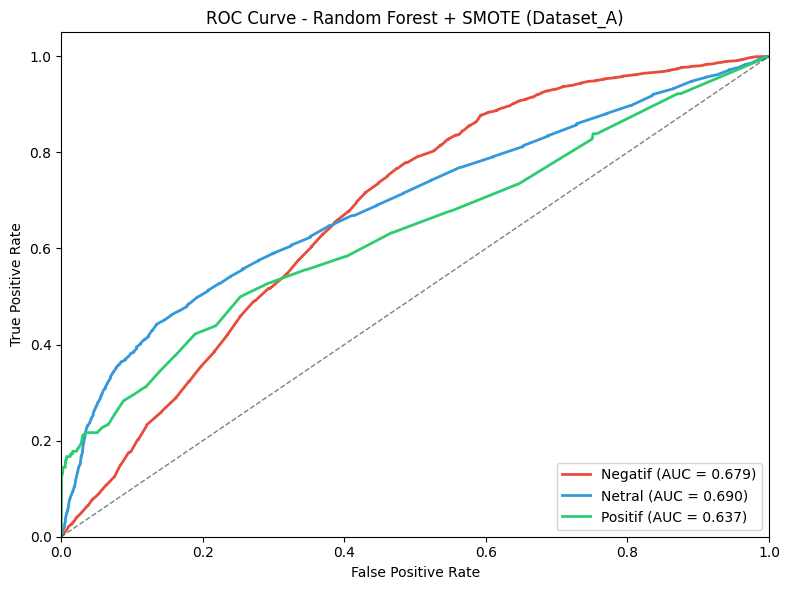

  Acc=0.7788 | F1=0.7613

[34/42] Random Forest + RUS (Dataset_A)

--- Classification Report: Random Forest + RUS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.86      0.50      0.63      5412
      Netral       0.35      0.50      0.41      1415
     Positif       0.06      0.57      0.10       180

    accuracy                           0.50      7007
   macro avg       0.42      0.52      0.38      7007
weighted avg       0.73      0.50      0.57      7007

  Saved: results/dataset_kesepakatan/Random_Forest/RUS_cm.png


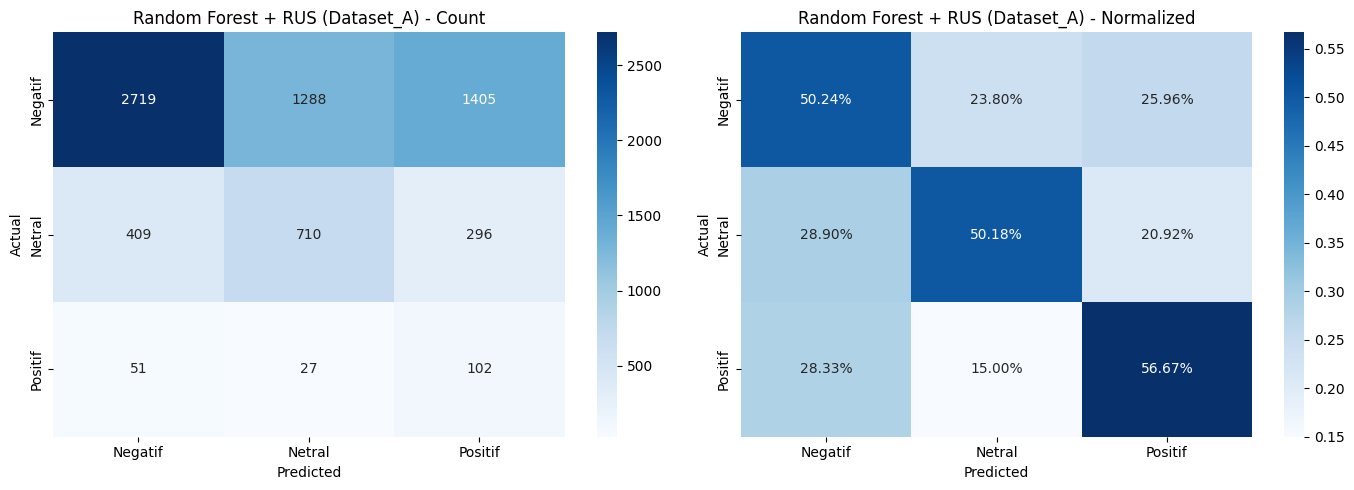

  Saved: results/dataset_kesepakatan/Random_Forest/RUS_roc.png


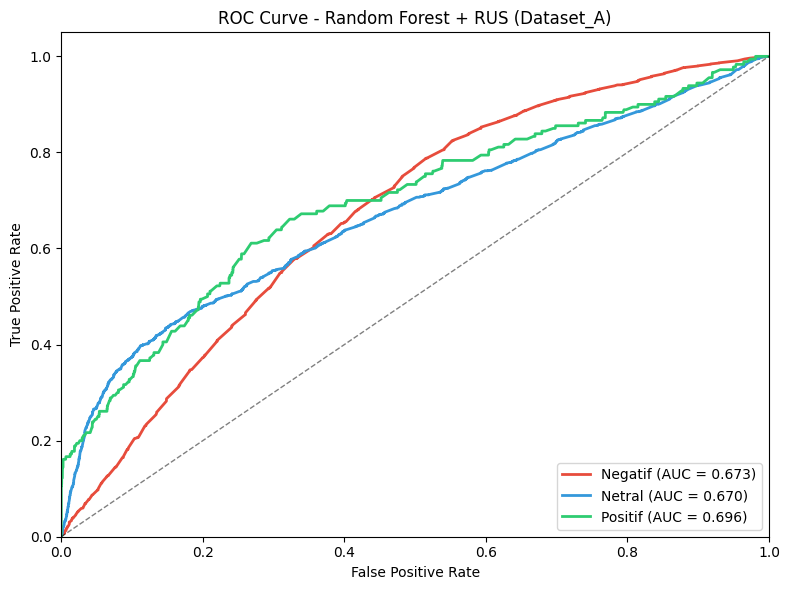

  Acc=0.5039 | F1=0.5749

[35/42] Random Forest + SMOTEENN (Dataset_A)

--- Classification Report: Random Forest + SMOTEENN (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.86      0.05      0.09      5412
      Netral       0.21      0.93      0.34      1415
     Positif       0.10      0.26      0.15       180

    accuracy                           0.23      7007
   macro avg       0.39      0.41      0.19      7007
weighted avg       0.71      0.23      0.14      7007

  Saved: results/dataset_kesepakatan/Random_Forest/SMOTEENN_cm.png


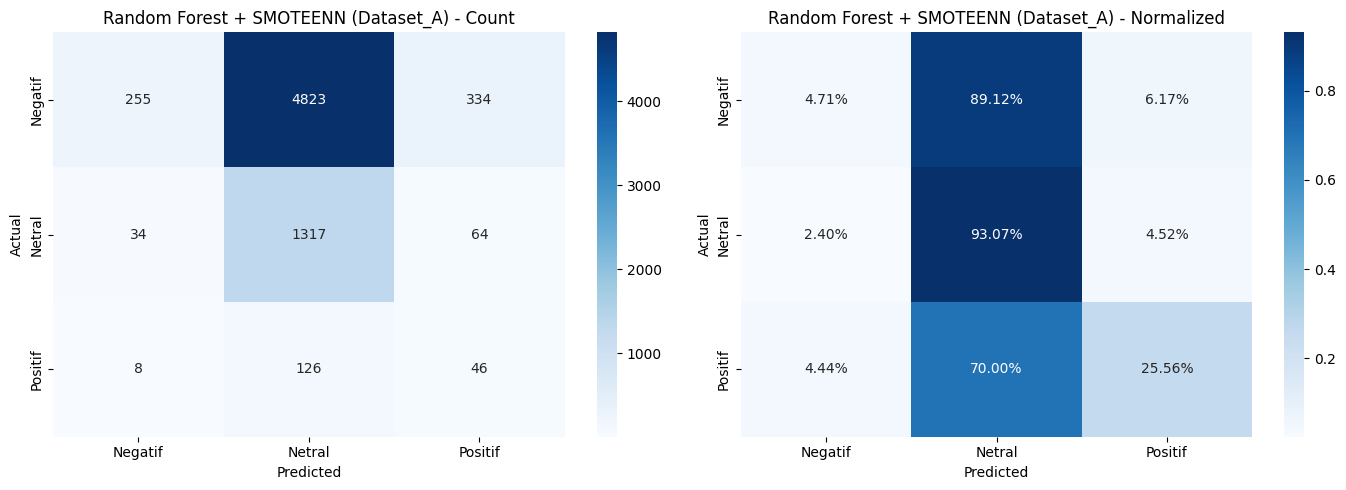

  Saved: results/dataset_kesepakatan/Random_Forest/SMOTEENN_roc.png


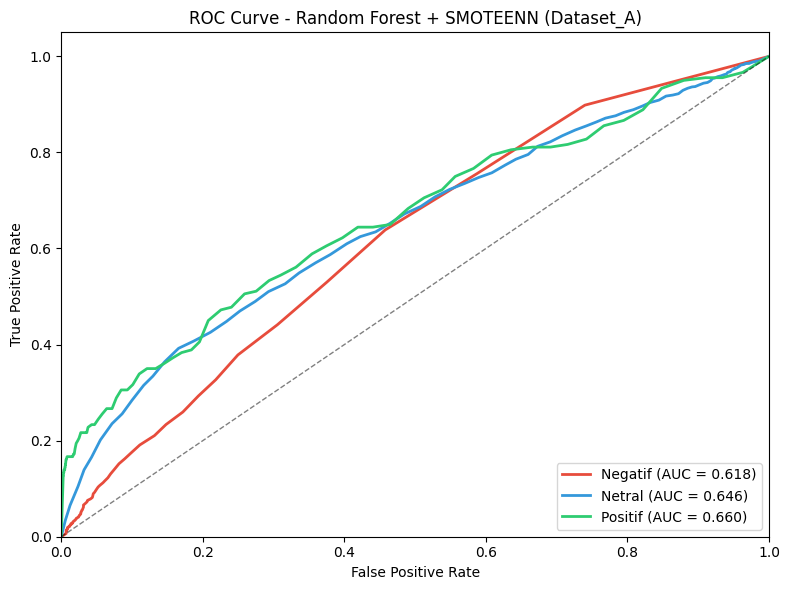

  Acc=0.2309 | F1=0.1420

[36/42] Random Forest + SMOTETomek (Dataset_A)

--- Classification Report: Random Forest + SMOTETomek (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.91      0.87      5412
      Netral       0.54      0.36      0.43      1415
     Positif       0.32      0.17      0.22       180

    accuracy                           0.78      7007
   macro avg       0.56      0.48      0.51      7007
weighted avg       0.76      0.78      0.76      7007

  Saved: results/dataset_kesepakatan/Random_Forest/SMOTETomek_cm.png


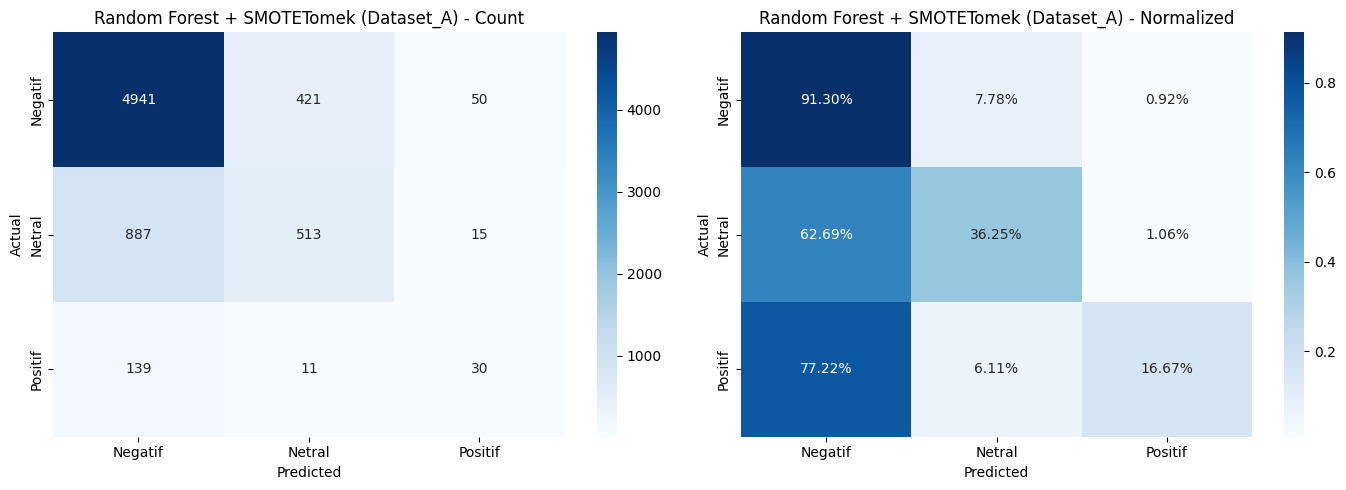

  Saved: results/dataset_kesepakatan/Random_Forest/SMOTETomek_roc.png


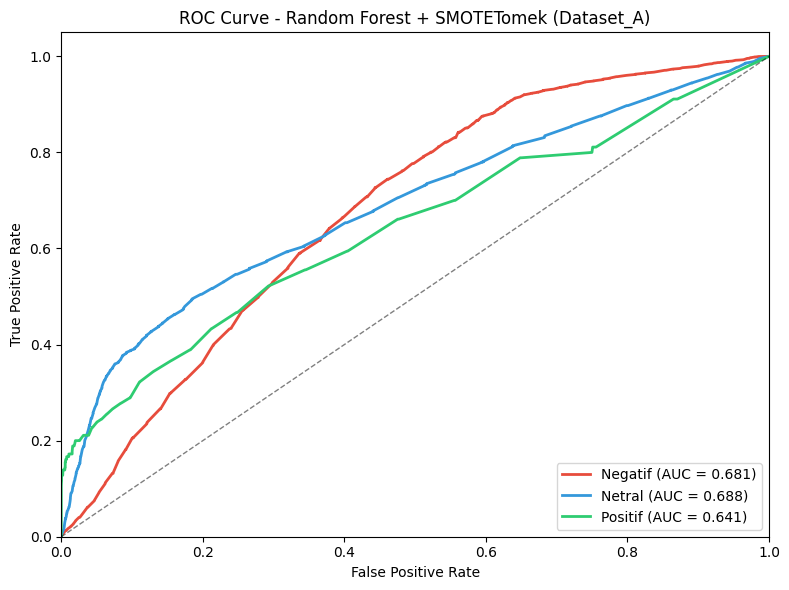

  Acc=0.7826 | F1=0.7642

[37/42] Logistic Regression + No_Balancing (Dataset_A)

--- Classification Report: Logistic Regression + No_Balancing (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.80      0.96      0.88      5412
      Netral       0.60      0.21      0.31      1415
     Positif       0.77      0.11      0.19       180

    accuracy                           0.79      7007
   macro avg       0.72      0.43      0.46      7007
weighted avg       0.76      0.79      0.75      7007

  Saved: results/dataset_kesepakatan/Logistic_Regression/No_Balancing_cm.png


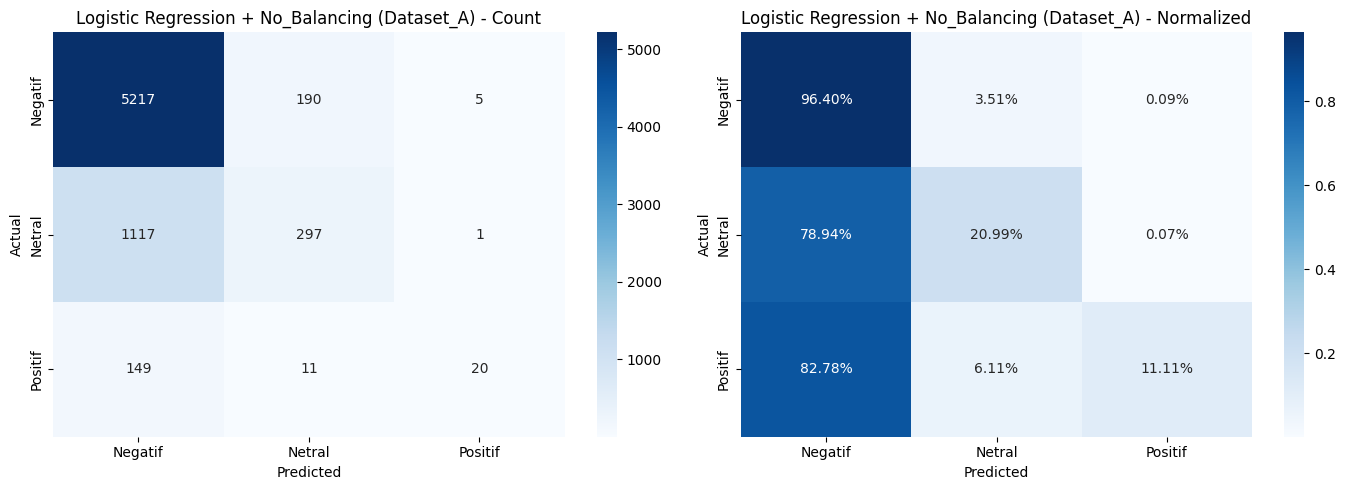

  Saved: results/dataset_kesepakatan/Logistic_Regression/No_Balancing_roc.png


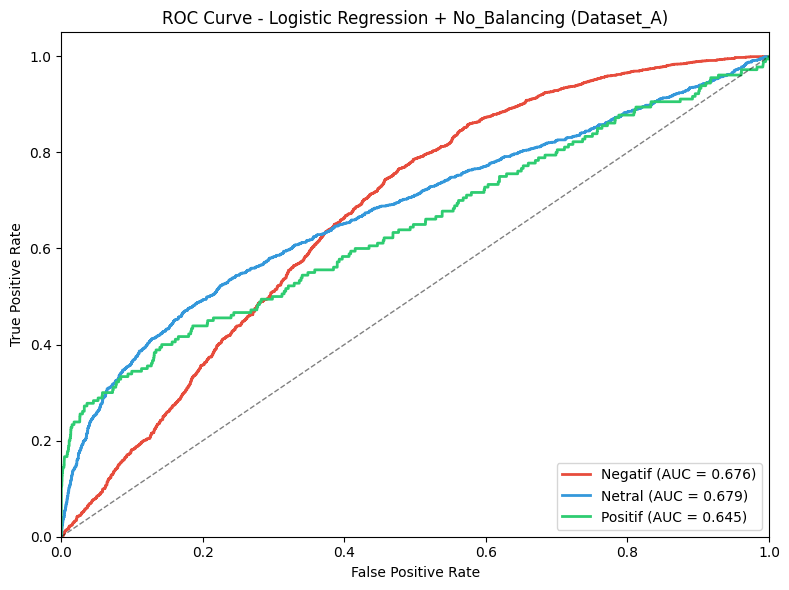

  Acc=0.7898 | F1=0.7452

[38/42] Logistic Regression + ROS (Dataset_A)

--- Classification Report: Logistic Regression + ROS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.84      0.68      0.75      5412
      Netral       0.34      0.49      0.41      1415
     Positif       0.08      0.28      0.12       180

    accuracy                           0.63      7007
   macro avg       0.42      0.48      0.43      7007
weighted avg       0.72      0.63      0.66      7007

  Saved: results/dataset_kesepakatan/Logistic_Regression/ROS_cm.png


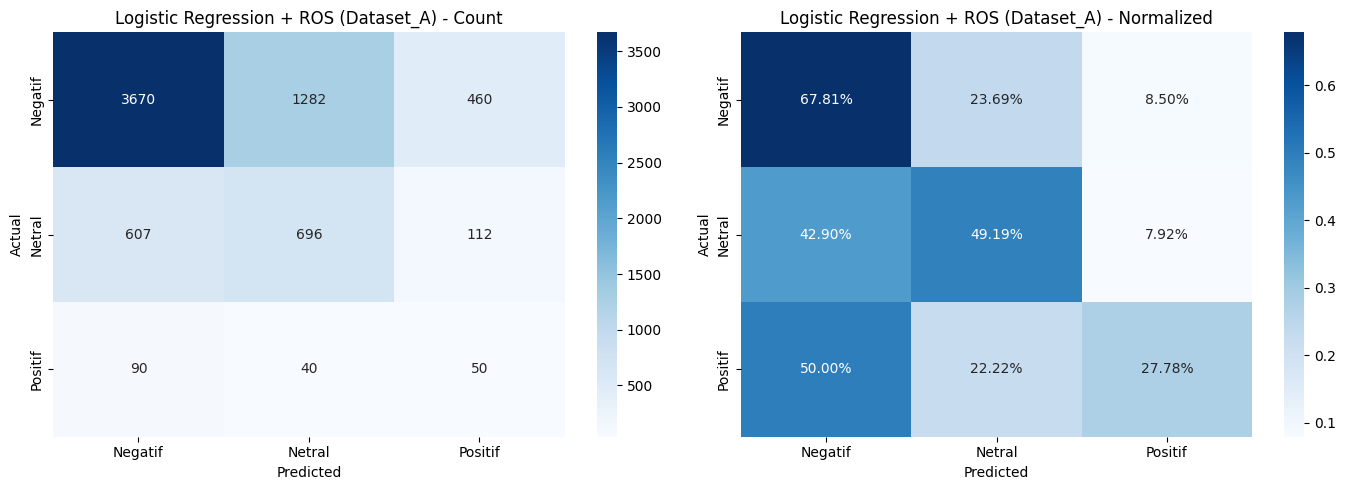

  Saved: results/dataset_kesepakatan/Logistic_Regression/ROS_roc.png


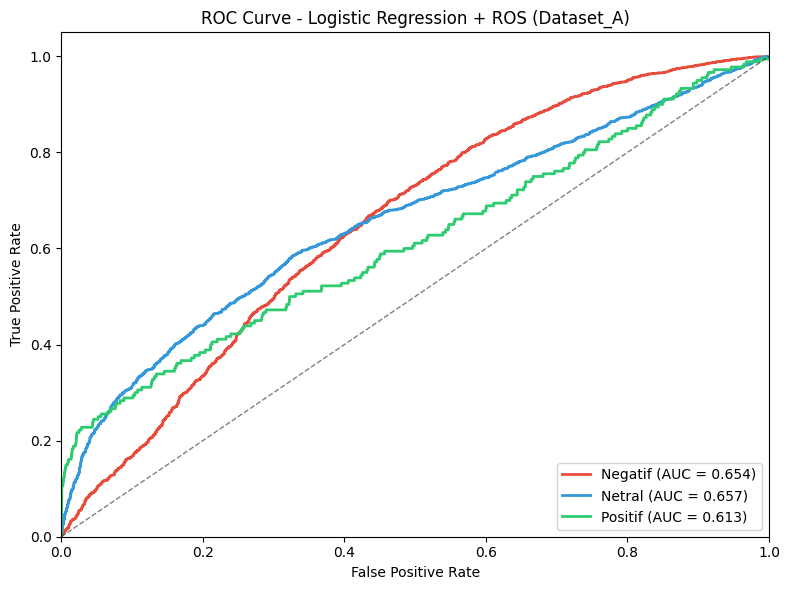

  Acc=0.6302 | F1=0.6648

[39/42] Logistic Regression + SMOTE (Dataset_A)

--- Classification Report: Logistic Regression + SMOTE (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.76      0.80      5412
      Netral       0.41      0.40      0.40      1415
     Positif       0.08      0.31      0.13       180

    accuracy                           0.68      7007
   macro avg       0.44      0.49      0.44      7007
weighted avg       0.73      0.68      0.70      7007

  Saved: results/dataset_kesepakatan/Logistic_Regression/SMOTE_cm.png


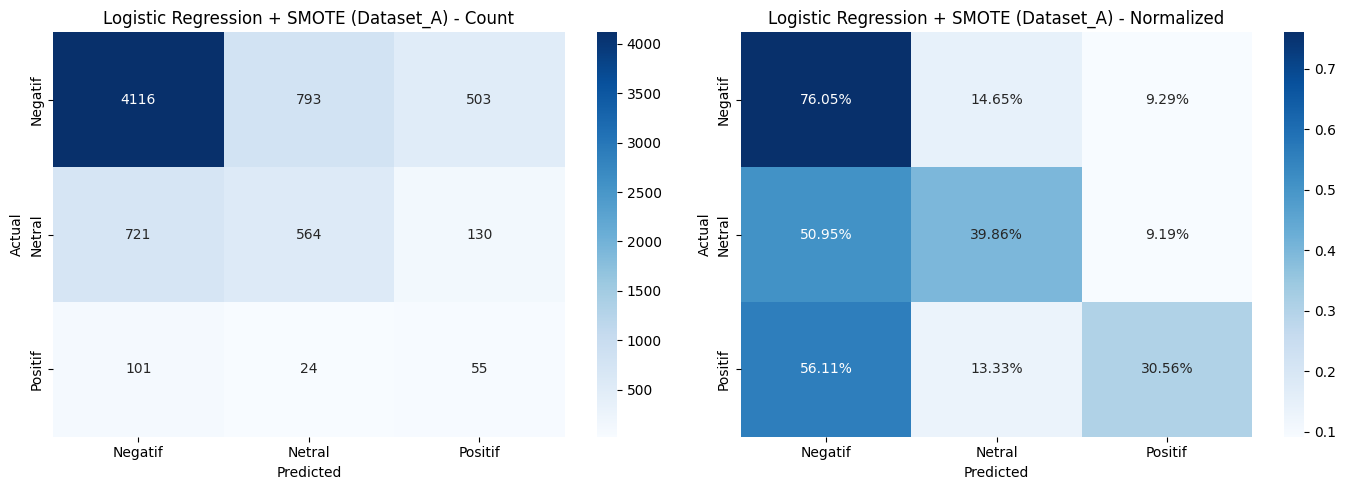

  Saved: results/dataset_kesepakatan/Logistic_Regression/SMOTE_roc.png


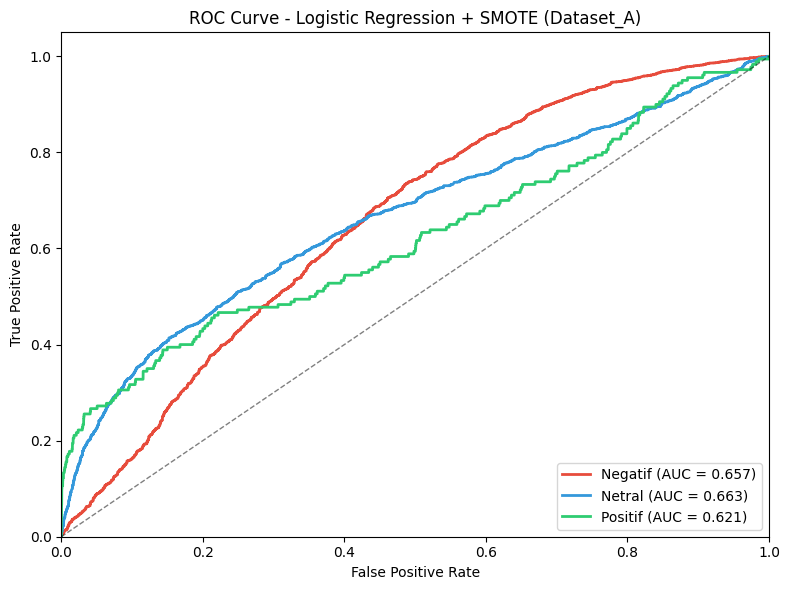

  Acc=0.6758 | F1=0.6990

[40/42] Logistic Regression + RUS (Dataset_A)

--- Classification Report: Logistic Regression + RUS (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.84      0.52      0.64      5412
      Netral       0.33      0.50      0.40      1415
     Positif       0.05      0.43      0.09       180

    accuracy                           0.51      7007
   macro avg       0.41      0.48      0.38      7007
weighted avg       0.72      0.51      0.58      7007

  Saved: results/dataset_kesepakatan/Logistic_Regression/RUS_cm.png


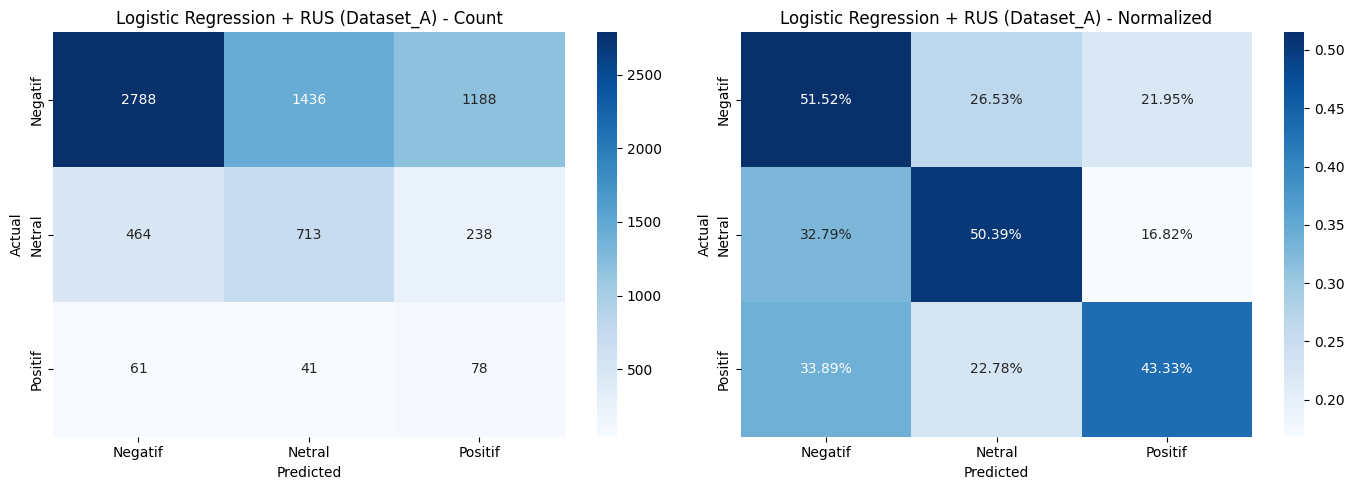

  Saved: results/dataset_kesepakatan/Logistic_Regression/RUS_roc.png


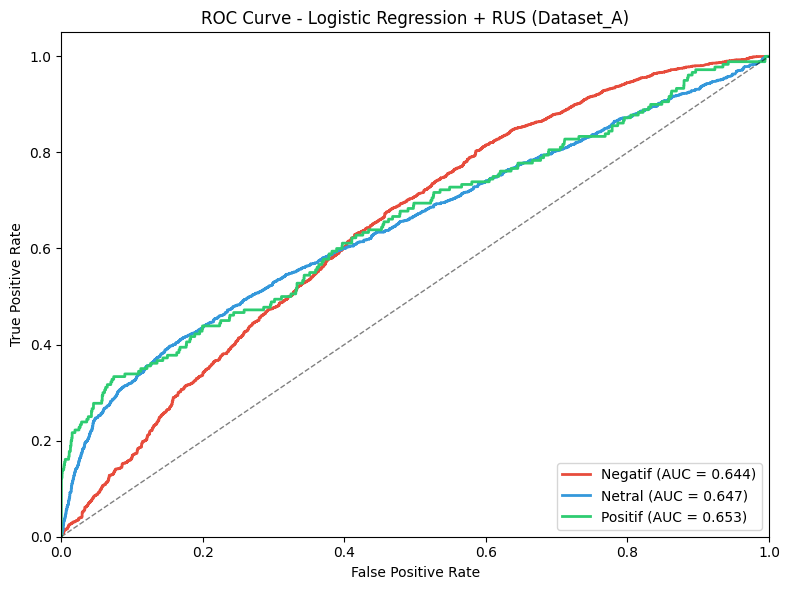

  Acc=0.5108 | F1=0.5759

[41/42] Logistic Regression + SMOTEENN (Dataset_A)

--- Classification Report: Logistic Regression + SMOTEENN (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.91      0.04      0.07      5412
      Netral       0.23      0.77      0.35      1415
     Positif       0.04      0.47      0.08       180

    accuracy                           0.20      7007
   macro avg       0.39      0.43      0.17      7007
weighted avg       0.75      0.20      0.13      7007

  Saved: results/dataset_kesepakatan/Logistic_Regression/SMOTEENN_cm.png


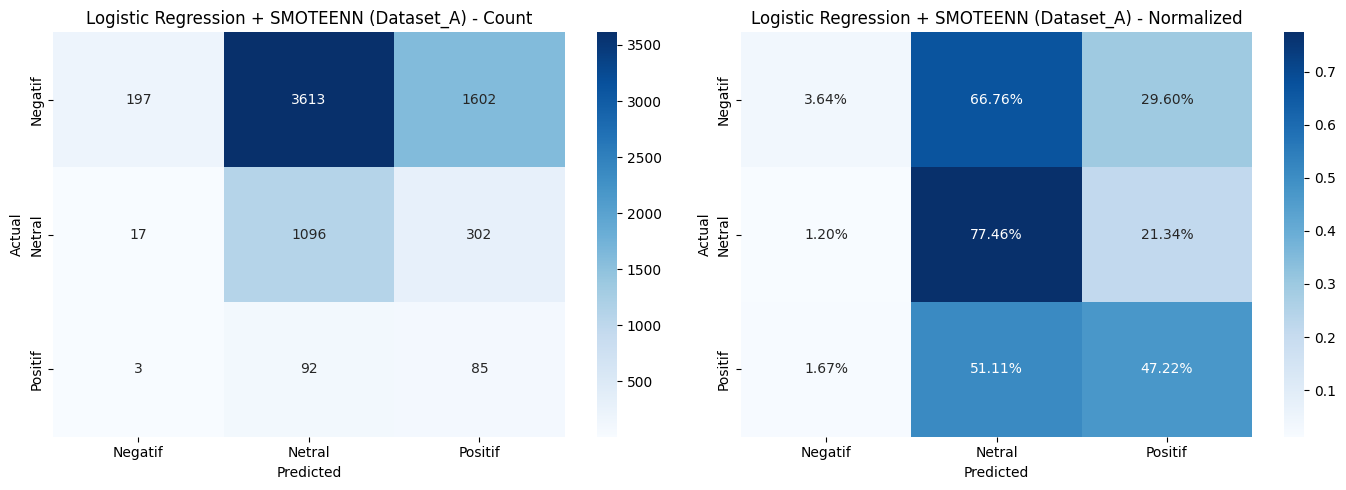

  Saved: results/dataset_kesepakatan/Logistic_Regression/SMOTEENN_roc.png


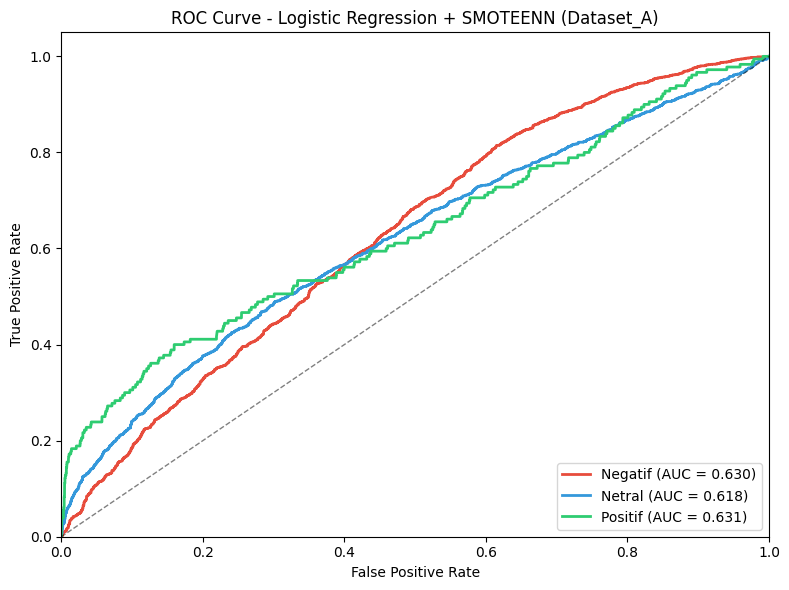

  Acc=0.1967 | F1=0.1273

[42/42] Logistic Regression + SMOTETomek (Dataset_A)

--- Classification Report: Logistic Regression + SMOTETomek (Dataset_A) ---
              precision    recall  f1-score   support

     Negatif       0.83      0.76      0.80      5412
      Netral       0.41      0.40      0.41      1415
     Positif       0.08      0.30      0.12       180

    accuracy                           0.68      7007
   macro avg       0.44      0.49      0.44      7007
weighted avg       0.73      0.68      0.70      7007

  Saved: results/dataset_kesepakatan/Logistic_Regression/SMOTETomek_cm.png


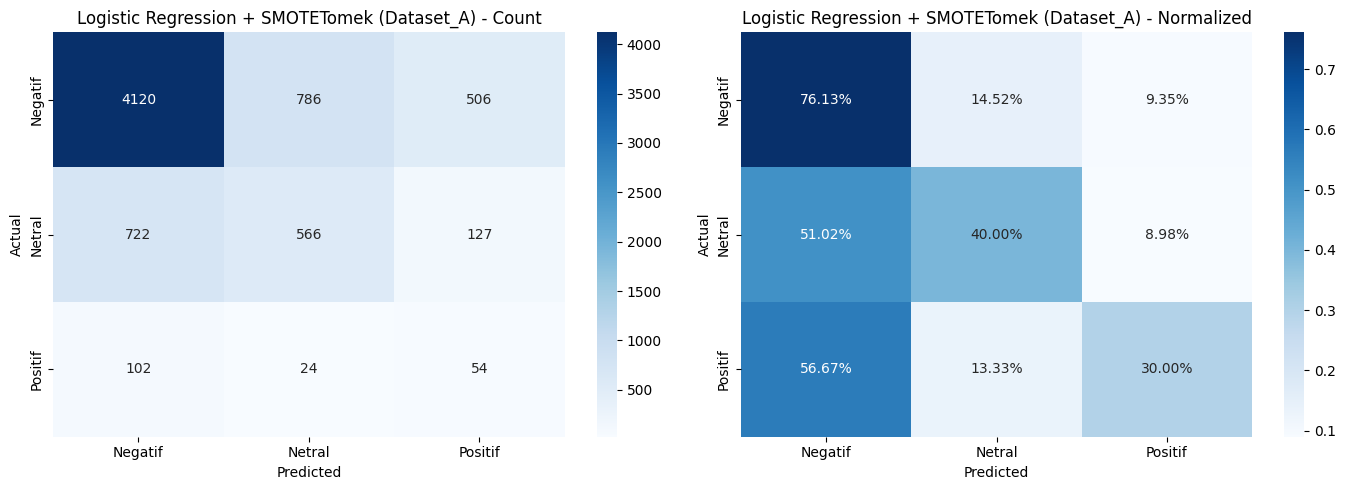

  Saved: results/dataset_kesepakatan/Logistic_Regression/SMOTETomek_roc.png


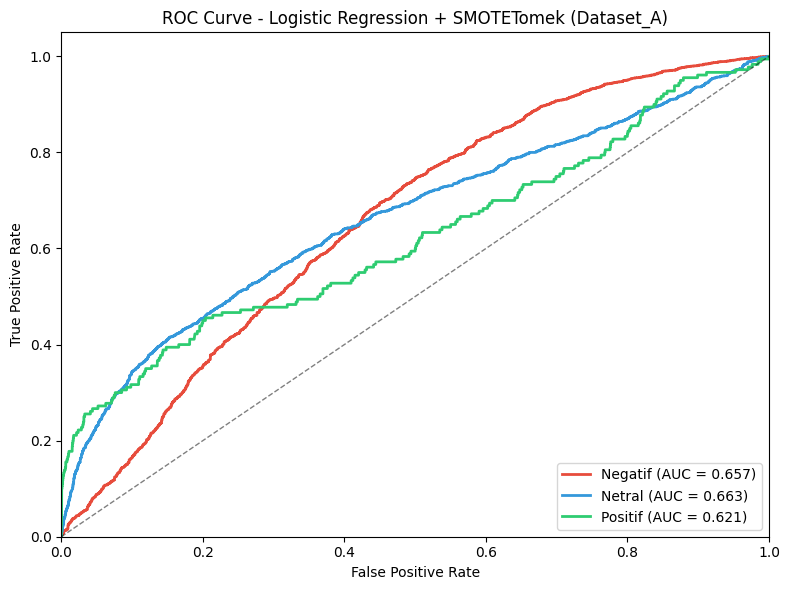

  Acc=0.6765 | F1=0.6997

Selesai!


In [14]:
DATASET_FOLDERS = {'Dataset_A': 'dataset_kesepakatan'}
total = len(data_prepared) * len(BALANCING_METHODS) * len(MODEL_CONFIGS)
counter = 0

for ds_name, (X_train, X_test, y_train_oh, y_test_oh) in data_prepared.items():
    y_true = np.argmax(y_test_oh, axis=1)

    for model_name, model_type in MODEL_CONFIGS.items():
        save_dir = f'results/{DATASET_FOLDERS[ds_name]}/{model_name.replace(" ","_")}'
        os.makedirs(save_dir, exist_ok=True)

        for bal_name, bal_class in BALANCING_METHODS.items():
            counter += 1
            tag = f'{model_name} + {bal_name} ({ds_name})'
            print(f"\n[{counter}/{total}] {tag}")

            # --- Balancing ---
            sampler = bal_class(random_state=SEED)
            X_bal, y_bal = sampler.fit_resample(X_train, y_train_oh)

            history = None
            y_pred_prob = None

            # --- Train ---
            if model_type == 'mlp_baseline':
                model = create_mlp_baseline(X_bal.shape[1])
                history = model.fit(X_bal, y_bal, epochs=50, batch_size=32,
                                    validation_split=0.15, callbacks=get_callbacks(), verbose=0)
                y_pred_prob = model.predict(X_test)
                y_pred = np.argmax(y_pred_prob, axis=1)
                del model; gc.collect(); K.clear_session()

            elif model_type == 'mlp_advance':
                model = create_mlp_advance(X_bal.shape[1])
                history = model.fit(X_bal, y_bal, epochs=50, batch_size=32,
                                    validation_split=0.15, callbacks=get_callbacks(), verbose=0)
                y_pred_prob = model.predict(X_test)
                y_pred = np.argmax(y_pred_prob, axis=1)
                del model; gc.collect(); K.clear_session()

            elif model_type == 'mlp_tuner':
                builder = make_tuner_builder(X_bal.shape[1])
                tuner = kt.RandomSearch(
                    builder, objective='val_accuracy', max_trials=5,
                    executions_per_trial=1,
                    directory=f'tuner_viz_{bal_name}_{ds_name}',
                    project_name='viz', overwrite=True
                )
                tuner.search(X_bal, y_bal, epochs=50, batch_size=32,
                             validation_split=0.15, callbacks=get_callbacks(), verbose=0)
                best_model = tuner.get_best_models(1)[0]
                y_pred_prob = best_model.predict(X_test)
                y_pred = np.argmax(y_pred_prob, axis=1)
                del best_model, tuner; gc.collect(); K.clear_session()

            else:  # sklearn
                y_bal_1d = np.argmax(y_bal, axis=1)
                if model_type == 'naive_bayes':
                    mdl = create_naive_bayes()
                elif model_type == 'svm':
                    mdl = create_svm(random_state=SEED)
                elif model_type == 'random_forest':
                    mdl = create_random_forest(random_state=SEED)
                elif model_type == 'logistic_regression':
                    mdl = create_logistic_regression(random_state=SEED)
                mdl.fit(X_bal, y_bal_1d)
                y_pred = mdl.predict(X_test)
                y_pred_prob = mdl.predict_proba(X_test)

            # --- Panggil fungsi evaluation.py ---
            prefix = f'{save_dir}/{bal_name}'

            print_classification_report(y_true, y_pred, title=tag)

            plot_confusion_matrix(y_true, y_pred, tag,
                                  save_path=f'{prefix}_cm.png')

            if y_pred_prob is not None:
                plot_roc_curve(y_true, y_pred_prob, tag,
                               save_path=f'{prefix}_roc.png')

            if history is not None:
                plot_learning_curve(history, tag,
                                    save_path=f'{prefix}_learning.png')

            print(f"  Acc={accuracy_score(y_true, y_pred):.4f} | F1={f1_score(y_true, y_pred, average='weighted'):.4f}")

print("\nSelesai!")